In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.special import genlaguerre, gammaln
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook'])
from scipy.sparse.linalg import eigsh

In [2]:
# ---------------------------------------------------------------------------
# Primitive sparse local operators
# ---------------------------------------------------------------------------

def _eye(d):
    return sp.eye(d, format='csr')

def _destroy(d):
    data = np.sqrt(np.arange(1, d, dtype=float))
    return sp.diags(data, 1, shape=(d, d), format='csr')

def _num(d):
    return sp.diags(np.arange(d, dtype=float), 0, format='csr')


# ---------------------------------------------------------------------------
# Sparse tensor-product embedding
# ---------------------------------------------------------------------------

def sparse_embed(ops_at_indices: dict, n_total: int, fock_dim: int) -> sp.csr_matrix:
    """
    Same semantics as your QuTiP embed(), but returns a scipy sparse matrix.
    ops_at_indices: {site_index: sparse_matrix}
    """
    local_ops = [_eye(fock_dim)] * n_total
    for idx, op in ops_at_indices.items():
        local_ops[idx] = op

    result = local_ops[0]
    for op in local_ops[1:]:
        result = sp.kron(result, op, format='csr')
    return result


# ---------------------------------------------------------------------------
# compute_position_exponential  (same logic, returns sparse)
# ---------------------------------------------------------------------------

def compute_position_exponential_sparse(N, u):
    matrix = np.zeros((N, N), dtype=complex)
    for m in range(N):
        for n in range(N):
            if m >= n:
                matrix[m, n] = (
                    np.exp(-u**2 / 2)
                    * np.exp(0.5 * (gammaln(n + 1) - gammaln(m + 1)))
                    * (1.0j * u) ** (m - n)
                    * genlaguerre(n, m - n)(u**2)
                )
            else:
                matrix[m, n] = (
                    np.exp(-u**2 / 2)
                    * np.exp(0.5 * (gammaln(m + 1) - gammaln(n + 1)))
                    * (1.0j * u) ** (n - m)
                    * genlaguerre(m, n - m)(u**2)
                )
    return sp.csr_matrix(matrix)

In [ ]:
def capacitive_ssh_sparse(N, fock_transmon, chi_C, Omega_C):    
    k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2)
    

    E_alpha = np.sqrt(1.0 + Omega_C * zeta_C)
    E_beta = np.sqrt(1.0 - Omega_C * zeta_C)
    
    # ground_state_energy = 0.5 * np.sum(E_alpha + E_beta) - N

    n_op = _num(fock_transmon)
    n_sites = 2 * N
    dim = fock_transmon ** n_sites

    H = sp.csr_matrix((dim, dim), dtype=complex)

    for j in range(N):
        # A-sublattice site: index 2j
        H += E_alpha[j] * sparse_embed({2 * j: n_op}, n_sites, fock_transmon)
        # B-sublattice site: index 2j+1
        H += E_beta[j] * sparse_embed({2 * j + 1: n_op}, n_sites, fock_transmon)

    # ground state energy: scalar * identity
    # H += ground_state_energy * sp.eye(dim, format='csr')
    return H

def k_sign(k, a=1.0):
    """Return +1 for k >= 0 or k == -π/a, else -1."""
    return np.where((k >= 0) | (np.isclose(k, -np.pi / a)), 1, -1)


def epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha'):
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2)
    if which == 'alpha':
        A = Omega_J/np.sqrt(1+Omega_C * zeta_C)
        B = 1+0.5 * Omega_C * zeta_C
        C = 2*chi_J - ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        D = 0.5 * Omega_C * zeta_C
        E = 2*chi_J + ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        epsilon = A * (B * C + D * E)
        return epsilon
    elif which == 'beta':
        A = Omega_J/np.sqrt(1-Omega_C * zeta_C)
        B = 1-0.5 * Omega_C * zeta_C
        C = 2*chi_J + ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        D = 0.5 * Omega_C * zeta_C
        E = 2*chi_J - ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        epsilon = A * (B * C + D * E)
        return epsilon
    else:
        return 0

def delta_sigma_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha'):
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2)
    if which == 'alpha':
        A = -k_sign(k_values) *  Omega_J/np.sqrt(1+Omega_C * zeta_C)
        B = 1+0.5 * Omega_C * zeta_C
        C = 2*chi_J + ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        D = 0.5 * Omega_C * zeta_C
        E = 2*chi_J - ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        delta = A * (B * C + D * E)
        return delta
    elif which == 'beta':
        A = -k_sign(k_values) * Omega_J/np.sqrt(1-Omega_C * zeta_C)
        B = 1-0.5 * Omega_C * zeta_C
        C = 2*chi_J - ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        D = 0.5 * Omega_C * zeta_C
        E = 2*chi_J + ((chi_J + chi_C) +(chi_J - chi_C) * np.cos(k_values))/zeta_C
        delta = A * (B * C + D * E)
        return delta
    else:
        return 0

def t_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J):
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2) 
    return Omega_J * (1 - chi_J * chi_C) * np.abs(np.sin(k_values)) * (1-(Omega_C * zeta_C)**2)**(1/4) / zeta_C

def delta_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J):
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2) 
    return -Omega_J * (1 - chi_J * chi_C) * np.sin(k_values) * (1-(Omega_C * zeta_C)**2)**(1/4) / zeta_C

def energy_offset_Josephson(N, k_values, chi_C, Omega_C, chi_J, Omega_J, phi0):
    eps_alpha = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='alpha')
    eps_beta  = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='beta')
    return 0.5 * np.sum(eps_alpha + eps_beta) - N - 4 * Omega_J * chi_J * (1.0/phi0**2 - 0.25)
# phi0 es la amplitud de las fluctuaciones del flujo reducido

def exact_josephson_ssh_sparse(N, fock_transmon, chi_C, Omega_C, chi_J, Omega_J):
    k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
    
    epsilon_alpha = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha')
    epsilon_beta = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'beta')
    
    delta_alpha = delta_sigma_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha')
    delta_beta = delta_sigma_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'beta')
    
    t_k = t_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J)
    delta_k = delta_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J)
    
    # energy_offset = energy_offset_Josephson(N, k_values, chi_C, Omega_C, chi_J, Omega_J, phi0)
    
    b_op = _destroy(fock_transmon)
    bd_op = b_op.T.conj()          # for csr, .conj().T
    n_op = _num(fock_transmon)
    n_sites = 2 * N
    dim = fock_transmon ** n_sites

    H = sp.csr_matrix((dim, dim), dtype=complex)

    for j in range(N):

        # --- diagonal ---
        H += epsilon_alpha[j] * sparse_embed({2 * j:     n_op}, n_sites, fock_transmon)
        H += epsilon_beta[j] * sparse_embed({2 * j + 1: n_op}, n_sites, fock_transmon)

        op_A = sparse_embed({2 * j: bd_op @ bd_op}, n_sites, fock_transmon)

        H += -0.5 * delta_alpha[j] * op_A
        H += -np.conj(delta_alpha[j]) * op_A.conj().T

        # --- self-pairing B ---
        op_B = sparse_embed({2 * j + 1: bd_op @ bd_op}, n_sites, fock_transmon)
        
        H += -0.5 * delta_beta[j] * op_B
        H += -np.conj(delta_beta[j]) * op_B.conj().T

        # --- hopping  b†_{A,j} b_{B,j}  +  h.c. ---
        op_hop = sparse_embed({2 * j: bd_op, 2 * j + 1: b_op}, n_sites, fock_transmon)
        H += t_k[j] * op_hop
        H += np.conj(t_k[j]) * op_hop.conj().T

        # --- intersite pairing  b†_{A,j} b†_{B,mj}  +  h.c. ---
        op_isp = sparse_embed({2 * j: bd_op, 2 * j + 1: bd_op}, n_sites, fock_transmon)
        H += delta_k[j] * op_isp
        H += np.conj(delta_k[j]) * op_isp.conj().T

    H += 1e-10 * sp.eye(dim, format='csr')
    return H

def excitation_conserving_josephson_ssh_sparse(N, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0):
    k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
    
    epsilon_alpha = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha')
    epsilon_beta = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which = 'beta')
    
    t_k = t_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J)
    
    # energy_offset = energy_offset_Josephson(N, k_values, chi_C, Omega_C, chi_J, Omega_J, phi0)
    
    b_op = _destroy(fock_transmon)
    bd_op = b_op.T.conj()          # for csr, .conj().T
    n_op = _num(fock_transmon)
    n_sites = 2 * N
    dim = fock_transmon ** n_sites

    H = sp.csr_matrix((dim, dim), dtype=complex)

    for j in range(N):

        # --- diagonal ---
        H += epsilon_alpha[j] * sparse_embed({2 * j:     n_op}, n_sites, fock_transmon)
        H += epsilon_beta[j] * sparse_embed({2 * j + 1: n_op}, n_sites, fock_transmon)

        # --- hopping  b†_{A,j} b_{B,j}  +  h.c. ---
        op_hop = sparse_embed({2 * j: bd_op, 2 * j + 1: b_op}, n_sites, fock_transmon)
        H += t_k[j] * op_hop
        H += np.conj(t_k[j]) * op_hop.conj().T

    H += 1e-10 * sp.eye(dim, format='csr')
    return H


def single_particle_josephson(N, k_index, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0):
    k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
    k_value = k_values[k_index]
    
    epsilon_alpha = epsilon_Josephson(k_value, chi_C, Omega_C, chi_J, Omega_J, which = 'alpha')
    epsilon_beta = epsilon_Josephson(k_value, chi_C, Omega_C, chi_J, Omega_J, which = 'beta')
    
    t_k = t_Josephson(k_value, chi_C, Omega_C, chi_J, Omega_J)
    
    # energy_offset = energy_offset_Josephson(N, k_values, chi_C, Omega_C, chi_J, Omega_J, phi0)
    
    b_op = _destroy(fock_transmon)
    bd_op = b_op.T.conj()          # for csr, .conj().T
    n_op = _num(fock_transmon)
    dim = fock_transmon**2
    H = sp.csr_matrix((dim, dim), dtype=complex)

    # --- diagonal ---
    H += epsilon_alpha * sparse_embed({0: n_op}, 2, fock_transmon)
    H += epsilon_beta * sparse_embed({1: n_op}, 2, fock_transmon)

    # --- hopping  b†_{A,j} b_{B,j}  +  h.c. ---
    op_hop = sparse_embed({0: bd_op, 1: b_op}, 2, fock_transmon)
    H += t_k * op_hop
    H += np.conj(t_k) * op_hop.conj().T

    H += 1e-10 * sp.eye(dim, format='csr')
    return H

def single_particle_capacitive(N, k_index, fock_transmon, chi_C, Omega_C):
    all_k  = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
    k_value = all_k[k_index]
    
    # zeta_C_all = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(all_k/2)**2)
    # E_alpha_all = np.sqrt(1.0 + Omega_C * zeta_C_all)
    # E_beta_all  = np.sqrt(1.0 - Omega_C * zeta_C_all)
    # ground_state_energy = 0.5 * np.sum(E_alpha_all + E_beta_all) - N  # correct global sum

    zeta_C  = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_value/2)**2)
    E_alpha = np.sqrt(1.0 + Omega_C * zeta_C)
    E_beta  = np.sqrt(1.0 - Omega_C * zeta_C)

    n_op = _num(fock_transmon)
    dim  = fock_transmon**2
    H    = sp.csr_matrix((dim, dim), dtype=complex)

    H += E_alpha * sparse_embed({0: n_op}, 2, fock_transmon)
    H += E_beta  * sparse_embed({1: n_op}, 2, fock_transmon)
    H += 1e-10 * sp.eye(dim, format='csr')
    return H

def ssh_squid_chain_sparse(N, k_index, fock_photon, fock_transmon, omega_r, gamma, chi_C, Omega_C, chi_J, Omega_J, phi0):
    """
    Sparse version of ssh_squid_chain.

    Hilbert space ordering:  photon ⊗ (transmon_0 ⊗ transmon_1 ⊗ ... ⊗ transmon_{2N-1})
    Total dimension: fock_photon * fock_transmon^(2N)
    """
    dim_transmon = fock_transmon
    # dim_photon   = fock_photon

    # --- photon sector ---
    H_ph   = omega_r * _num(fock_photon)                          # fock_photon × fock_photon
    sin_op = -0.5j * (
        compute_position_exponential_sparse(fock_photon,  gamma)
        - compute_position_exponential_sparse(fock_photon, -gamma)
    )                                                              # fock_photon × fock_photon

    eye_ph  = _eye(fock_photon)
    eye_tr  = sp.eye(dim_transmon**2, format='csr')

    # --- chain sectors ---
    H0 = single_particle_capacitive(N, k_index, fock_transmon, chi_C, Omega_C)
    H1 = single_particle_josephson(N, k_index, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0)

    # --- combine with kron (photon is the leftmost/slowest index) ---
    H = (
        sp.kron(H_ph,   eye_tr,  format='csr')   # H_ph  ⊗ I_transmon
        + sp.kron(eye_ph, H0,    format='csr')   # I_ph  ⊗ H0
        - sp.kron(sin_op, H1,    format='csr')   # sin   ⊗ H1
    )
    return H

def linear_ssh_squid_chain_sparse(N, k_index, fock_photon, fock_transmon, omega_r, gamma, chi_C, Omega_C, chi_J, Omega_J, phi0):
    """
    Sparse version of ssh_squid_chain.

    Hilbert space ordering:  photon ⊗ (transmon_0 ⊗ transmon_1 ⊗ ... ⊗ transmon_{2N-1})
    Total dimension: fock_photon * fock_transmon^(2N)
    """
    dim_transmon = fock_transmon
    # dim_photon   = fock_photon

    # --- photon sector ---
    H_ph   = omega_r * _num(fock_photon)                          # fock_photon × fock_photon
    sin_op = gamma * (_destroy(fock_photon) + _destroy(fock_photon).conj().T)

    eye_ph  = _eye(fock_photon)
    eye_tr  = sp.eye(dim_transmon**2, format='csr')

    # --- chain sectors ---
    H0 = single_particle_capacitive(N, k_index, fock_transmon, chi_C, Omega_C)
    H1 = single_particle_josephson(N, k_index, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0)

    # --- combine with kron (photon is the leftmost/slowest index) ---
    H = (
        sp.kron(H_ph,   eye_tr,  format='csr')   # H_ph  ⊗ I_transmon
        + sp.kron(eye_ph, H0,    format='csr')   # I_ph  ⊗ H0
        - sp.kron(sin_op, H1,    format='csr')   # sin   ⊗ H1
    )
    return H

In [10]:
N = 4
fock_transmon = 4
chi_C = 0.5
Omega_C_values = np.linspace(0.1, 0.9, 10)
chi_J = 0
Omega_J = 0.1
phi0 = 1.0
eigenvalues1 = []
eigenvalues2 = []

for Omega_C in Omega_C_values:
    H1 = exact_josephson_ssh_sparse(N, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0)
    H2 = excitation_conserving_josephson_ssh_sparse(N, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0)
    eigenvalues1.append(eigsh(H1, k = 20, return_eigenvectors= False))
    eigenvalues2.append(eigsh(H2, k = 20, return_eigenvectors= False))

KeyboardInterrupt: 

In [ ]:
eigenvalues1 = np.array(eigenvalues1)-np.min(eigenvalues1)
eigenvalues2 = np.array(eigenvalues2) - np.min(eigenvalues2)

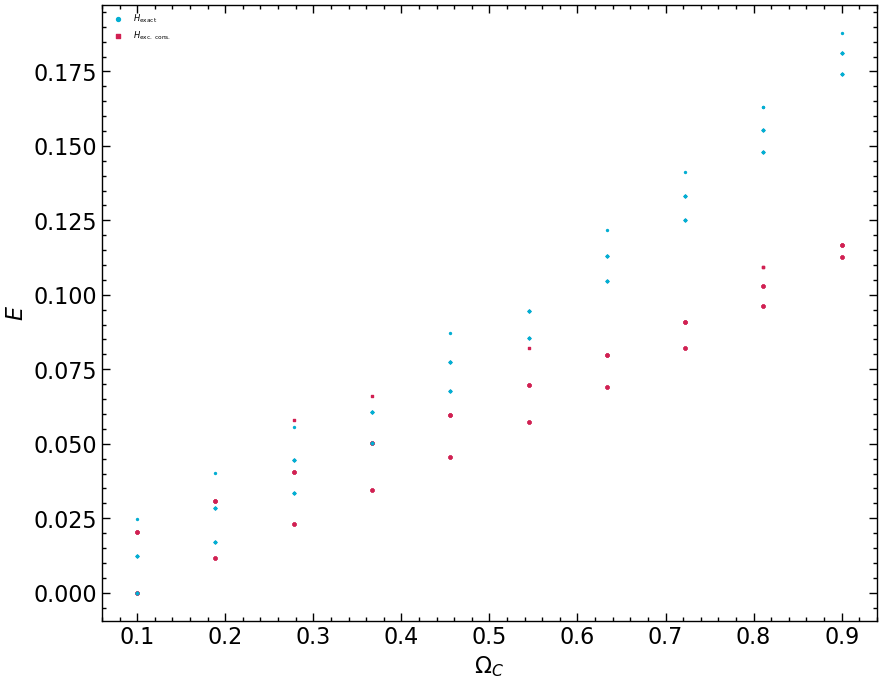

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    np.repeat(Omega_C_values, eigenvalues1.shape[1]),
    eigenvalues1.flatten(),
    s=2, color='#03AED2', label=r'$H_\mathrm{exact}$', zorder=2
)
ax.scatter(
    np.repeat(Omega_C_values, eigenvalues2.shape[1]),
    eigenvalues2.flatten(),
    s=2, color='#D12052', marker='s', label=r'$H_\mathrm{exc.\ cons.}$', zorder=1
)

ax.set_xlabel(r'$\Omega_C$')
ax.set_ylabel(r'$E$')
ax.legend(fontsize=6, framealpha=0, markerscale=2)

# fig.savefig('spectrum_vs_OmegaC.pdf', bbox_inches='tight')
plt.show()

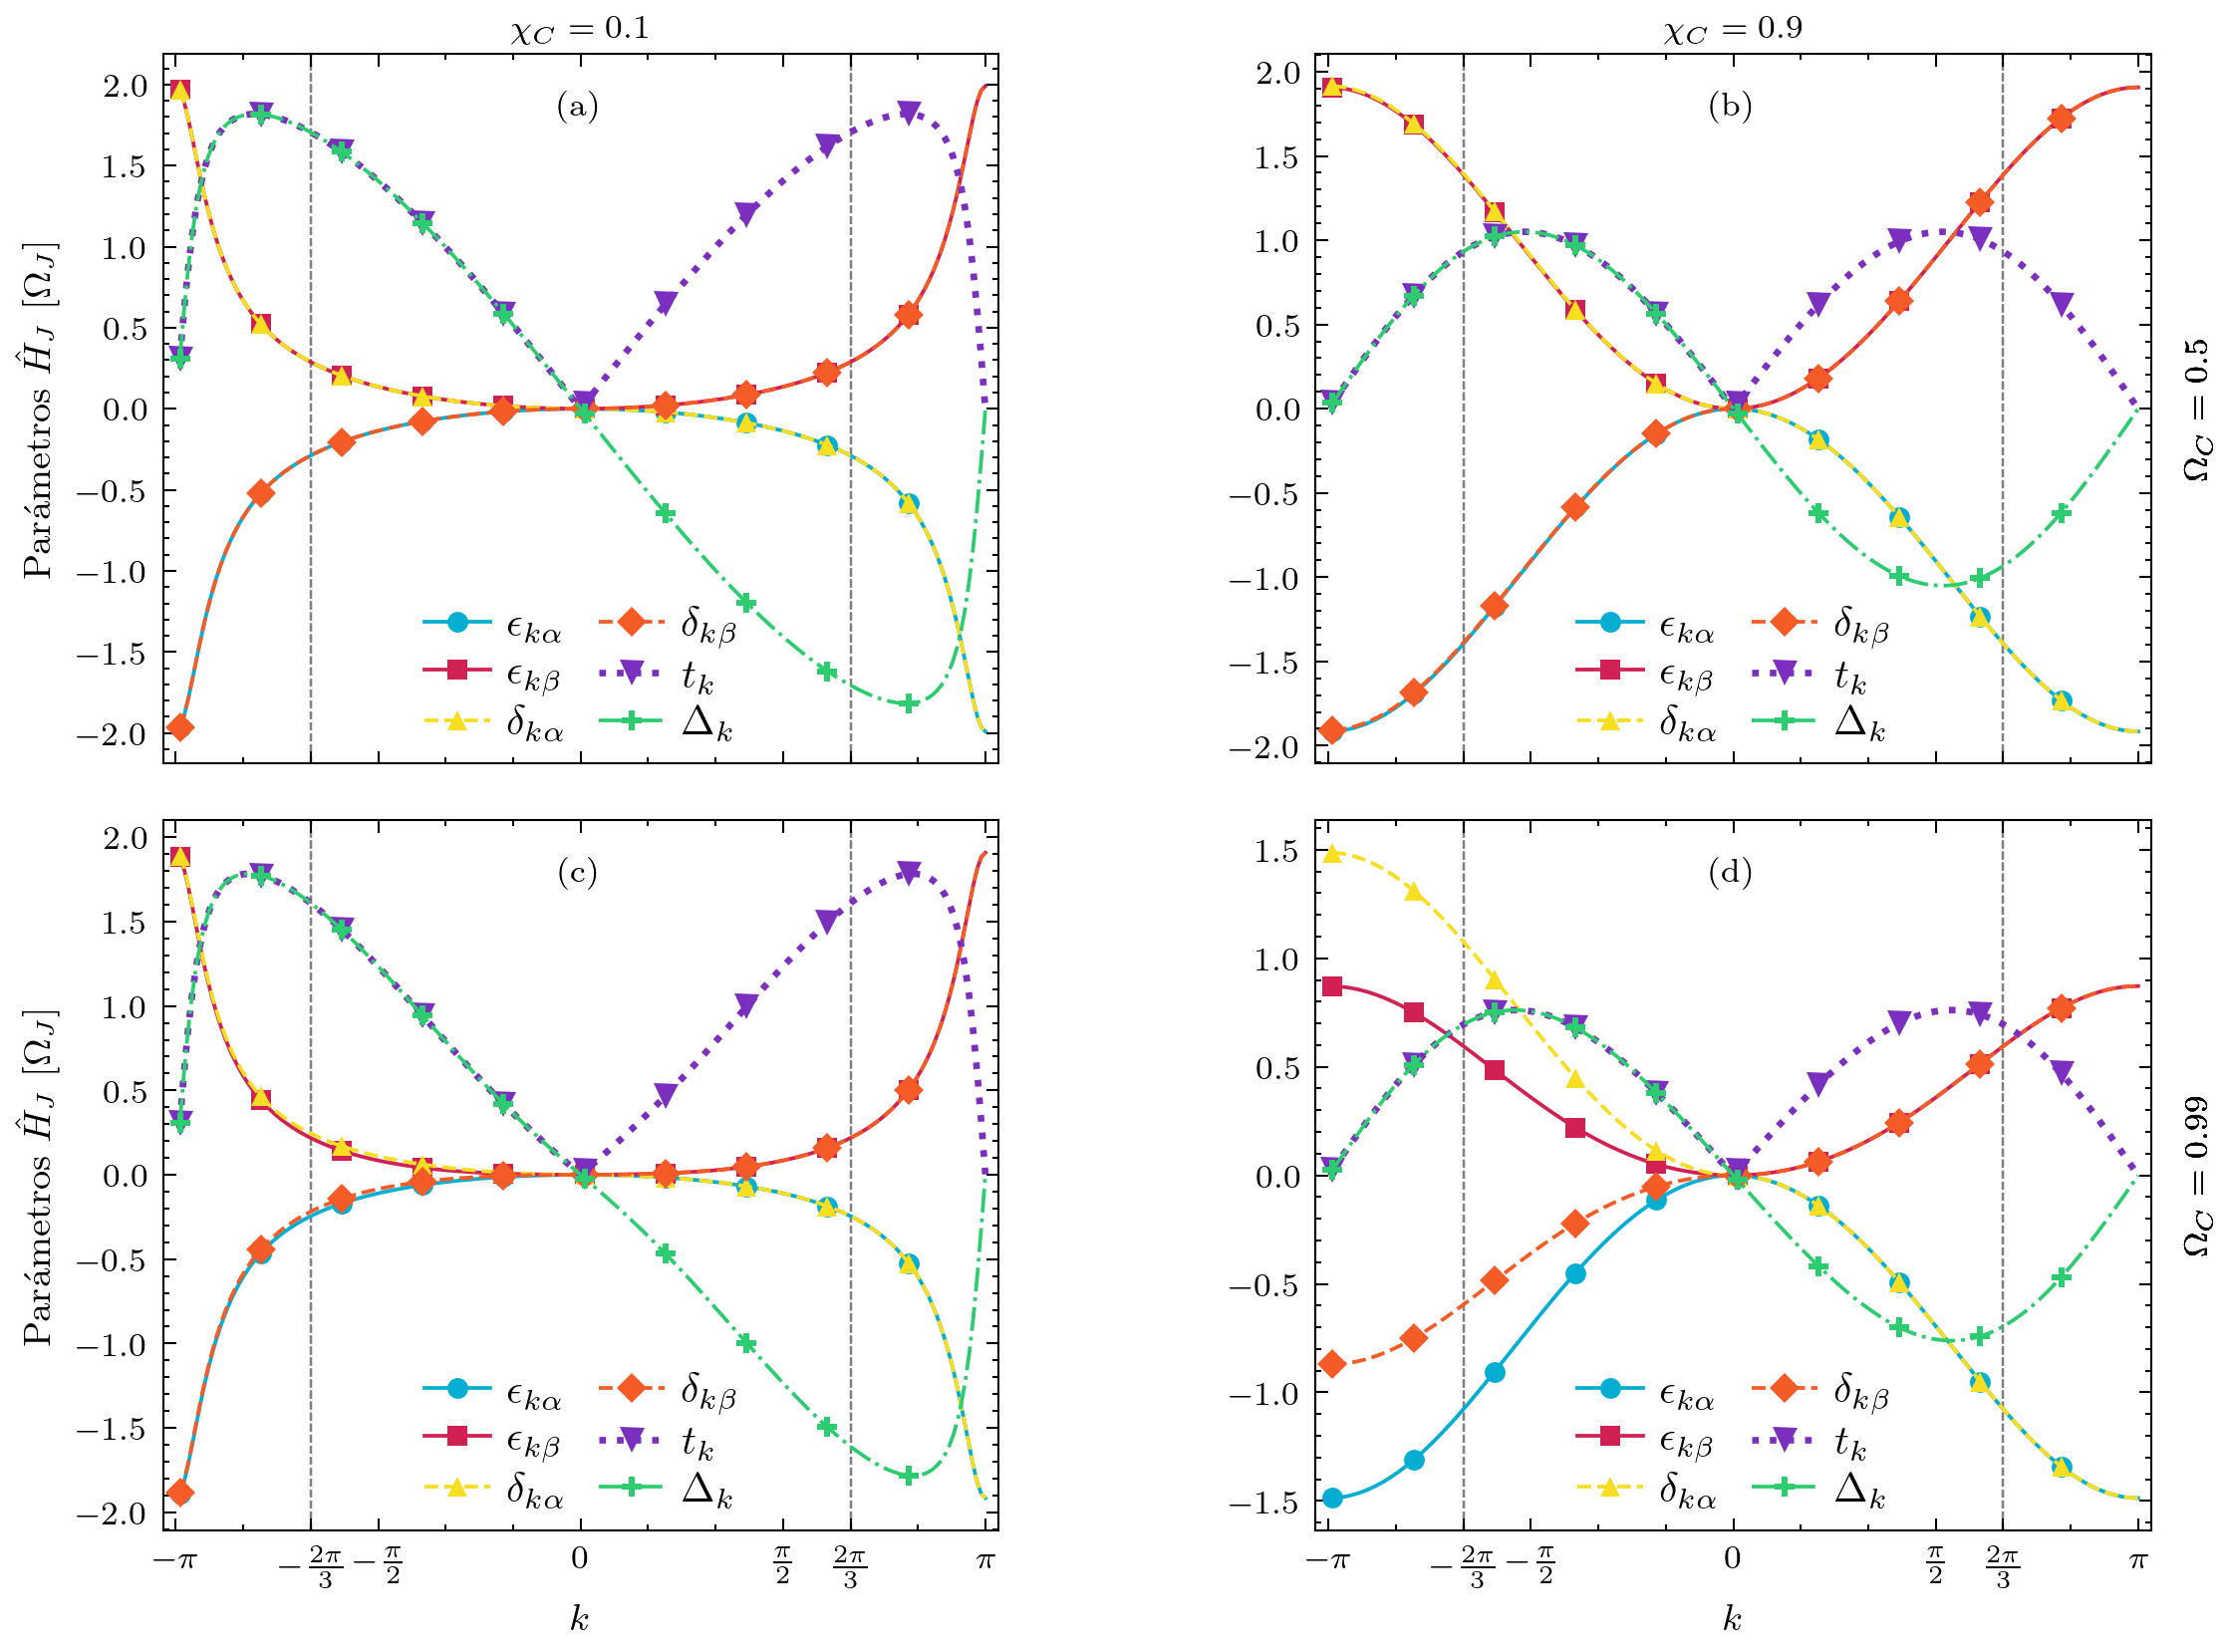

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── PRB-style rcParams (from your second block) ──────────────────────────────
mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'text.usetex':       True,
    'font.size':         9,
    'axes.labelsize':    9,
    'legend.fontsize':   7,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'axes.linewidth':    0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  1.5,
    'ytick.minor.size':  1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'figure.dpi':        300,
})

# ── Parameters ────────────────────────────────────────────────────────────────
chi_J = 0
Omega_J = 1.0
# Four panels: all combinations of two Omega_C and two chi_C values
Omega_C_values = [0.1,  0.1,  0.9, 0.9]
chi_C_values   = [0.1,  0.9,  0.1,  0.9 ]

N_k = 200
k_raw = np.fft.fftshift(np.fft.fftfreq(N_k, d=1.0 / (2 * np.pi)))
k_values = np.where(k_raw < -np.pi + 1e-10, k_raw + 2 * np.pi, k_raw)
order    = np.argsort(k_values)
k_values = k_values[order]   # sorted, runs from ~−π+ε to +π

colors  = ['#03AED2', '#D12052', '#F8DE22', '#F45B26', '#7B2FBE', '#2ECC71']
lss     = ['-', '-', '--', '--', ':', '-.']
labels  = [
    r'$\epsilon_{k\alpha}$',
    r'$\epsilon_{k\beta}$',
    r'$\delta_{k\alpha}$',
    r'$\delta_{k\beta}$',
    r'$t_k$',
    r'$\Delta_k$',
]

mark_every = 20   # sparser markers look cleaner at PRB column width
ms         = 5
markers    = ['o', 's', '^', 'D', 'v', 'P']

# ── Figure: 2 × 2, PRB double-column width ───────────────────────────────────
# PRB double column ≈ 7.0 in; single column ≈ 3.4 in
fig, axes = plt.subplots(nrows=2, ncols=2,
                         figsize=(7.0, 5.2),
                         sharex=True, sharey=False)
fig.tight_layout(pad=0.3)          # preliminary call; overridden below
fig.subplots_adjust(hspace=0.08, wspace=0.38)

panel_labels = ['(a)', '(b)', '(c)', '(d)']

for idx, (ax, Omega_C, chi_C) in enumerate(
        zip(axes.flatten(), Omega_C_values, chi_C_values)):

    epsilon_alpha = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='alpha')
    epsilon_beta  = epsilon_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='beta')
    delta_alpha   = delta_sigma_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='alpha')
    delta_beta    = delta_sigma_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J, which='beta')
    t_k           = t_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J)
    delta_k       = delta_Josephson(k_values, chi_C, Omega_C, chi_J, Omega_J)

    curves = [epsilon_alpha, epsilon_beta, delta_alpha, delta_beta, t_k, delta_k]

    for y, lab, c, ls, mk in zip(curves, labels, colors, lss, markers):
        lw = 1.6 if lab == r'$t_k$' else 0.9
        ms = 6 if lab == r'$t_k$' else 5
        ax.plot(k_values, y,
            label=lab, color=c, ls=ls, lw=lw,
            marker=mk, markevery=mark_every,
            markersize=ms, markerfacecolor=c,
            markeredgewidth=0.0)
    
        for kmark in [-2*np.pi/3, 2*np.pi/3]:
            ax.axvline(kmark, color='gray', lw=0.5, ls='--', zorder=0)
    

        # --- column headers: chi_C on top of each column ---
    for col, chi_C in enumerate([0.1, 0.9]):
        axes[0, col].set_title(
            rf'$\chi_C = {chi_C}$',
            fontsize=8, pad=4
        )

    # --- row headers: Omega_C on right side of each row ---
    for row, Omega_C in enumerate([0.5, 0.99]):
        axes[row, -1].annotate(
            rf'$\Omega_C = {Omega_C}$',
            xy=(1.04, 0.5), xycoords='axes fraction',
            fontsize=8, va='center', ha='left',
            rotation=90
        )

    # Panel label (a)–(d) inside top-left corner
    ax.text(0.5, 0.95, panel_labels[idx],
        transform=ax.transAxes,
        fontsize=8, va='top', ha='center')

    # Subtitle as text annotation (avoids suptitle clash)
    # ax.set_title(r'$\chi_C=%g,\;\Omega_C=%g$' % (chi_C, Omega_C),
    #              fontsize=8, pad=3)

    # x ticks: −π shown as −π, NOT relabeled; +π shown as +π
    border_pad_plot = 0.1
    ax.set_xticks([-np.pi, -2*np.pi/3, -np.pi/2, 0, np.pi/2, 2*np.pi/3, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\frac{2\pi}{3}$', r'$-\frac{\pi}{2}$',
                    r'$0$', r'$\frac{\pi}{2}$', r'$\frac{2\pi}{3}$', r'$\pi$'])
    ax.set_xlim(-np.pi-border_pad_plot, np.pi+border_pad_plot)

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # x-label only on bottom row
    if idx >= 2:
        ax.set_xlabel(r'$k$')

    # y-label on left column only
    if idx % 2 == 0:
        ax.set_ylabel(r'Parámetros $\hat H_J$ $[\Omega_J]$')

    ax.legend(frameon=False,
              ncol=2,
              handlelength=1.6,
              handletextpad=0.4,
              borderpad=0,
              labelspacing=0.25,
              columnspacing=0.8,
              fontsize = 10,
              loc = 'lower center')

fig.savefig('../../../figures/export/josephson_coefficients.pdf', bbox_inches='tight', dpi=600)
plt.show()

In [23]:
N = 60
fock_photon = 10
fock_transmon = 10
# omega_r = 0.3
gamma = 0.01

Omega_J = 1.0
chi_C = 0.5
Omega_C = 0.46
chi_J = 0
phi0 = 1
aux = 0.5 * Omega_C * np.sqrt(1+3*chi_C**2)
omega_r = np.sqrt(1+aux) - np.sqrt(1-aux)

eigenenergies = []
energies0 = []
for k_index in range(N):
    H = ssh_squid_chain_sparse(N, k_index, fock_photon, fock_transmon, omega_r, gamma, chi_C, Omega_C, chi_J, Omega_J, phi0)
    # H = single_particle_josephson(N, k_index, fock_transmon, chi_C, Omega_C, chi_J, Omega_J, phi0)
    H_0 = single_particle_capacitive(N, k_index, fock_transmon, chi_C, Omega_C)
    eigenenergies.append(eigsh(H, k = 30, which = 'SA', return_eigenvectors = False))
    # energies0.append(np.sort(H_0.diagonal())[:10])    
    energies0.append(eigsh(H_0, k = 30, which = 'SA', return_eigenvectors = False))
    

(-0.05, 2.5)

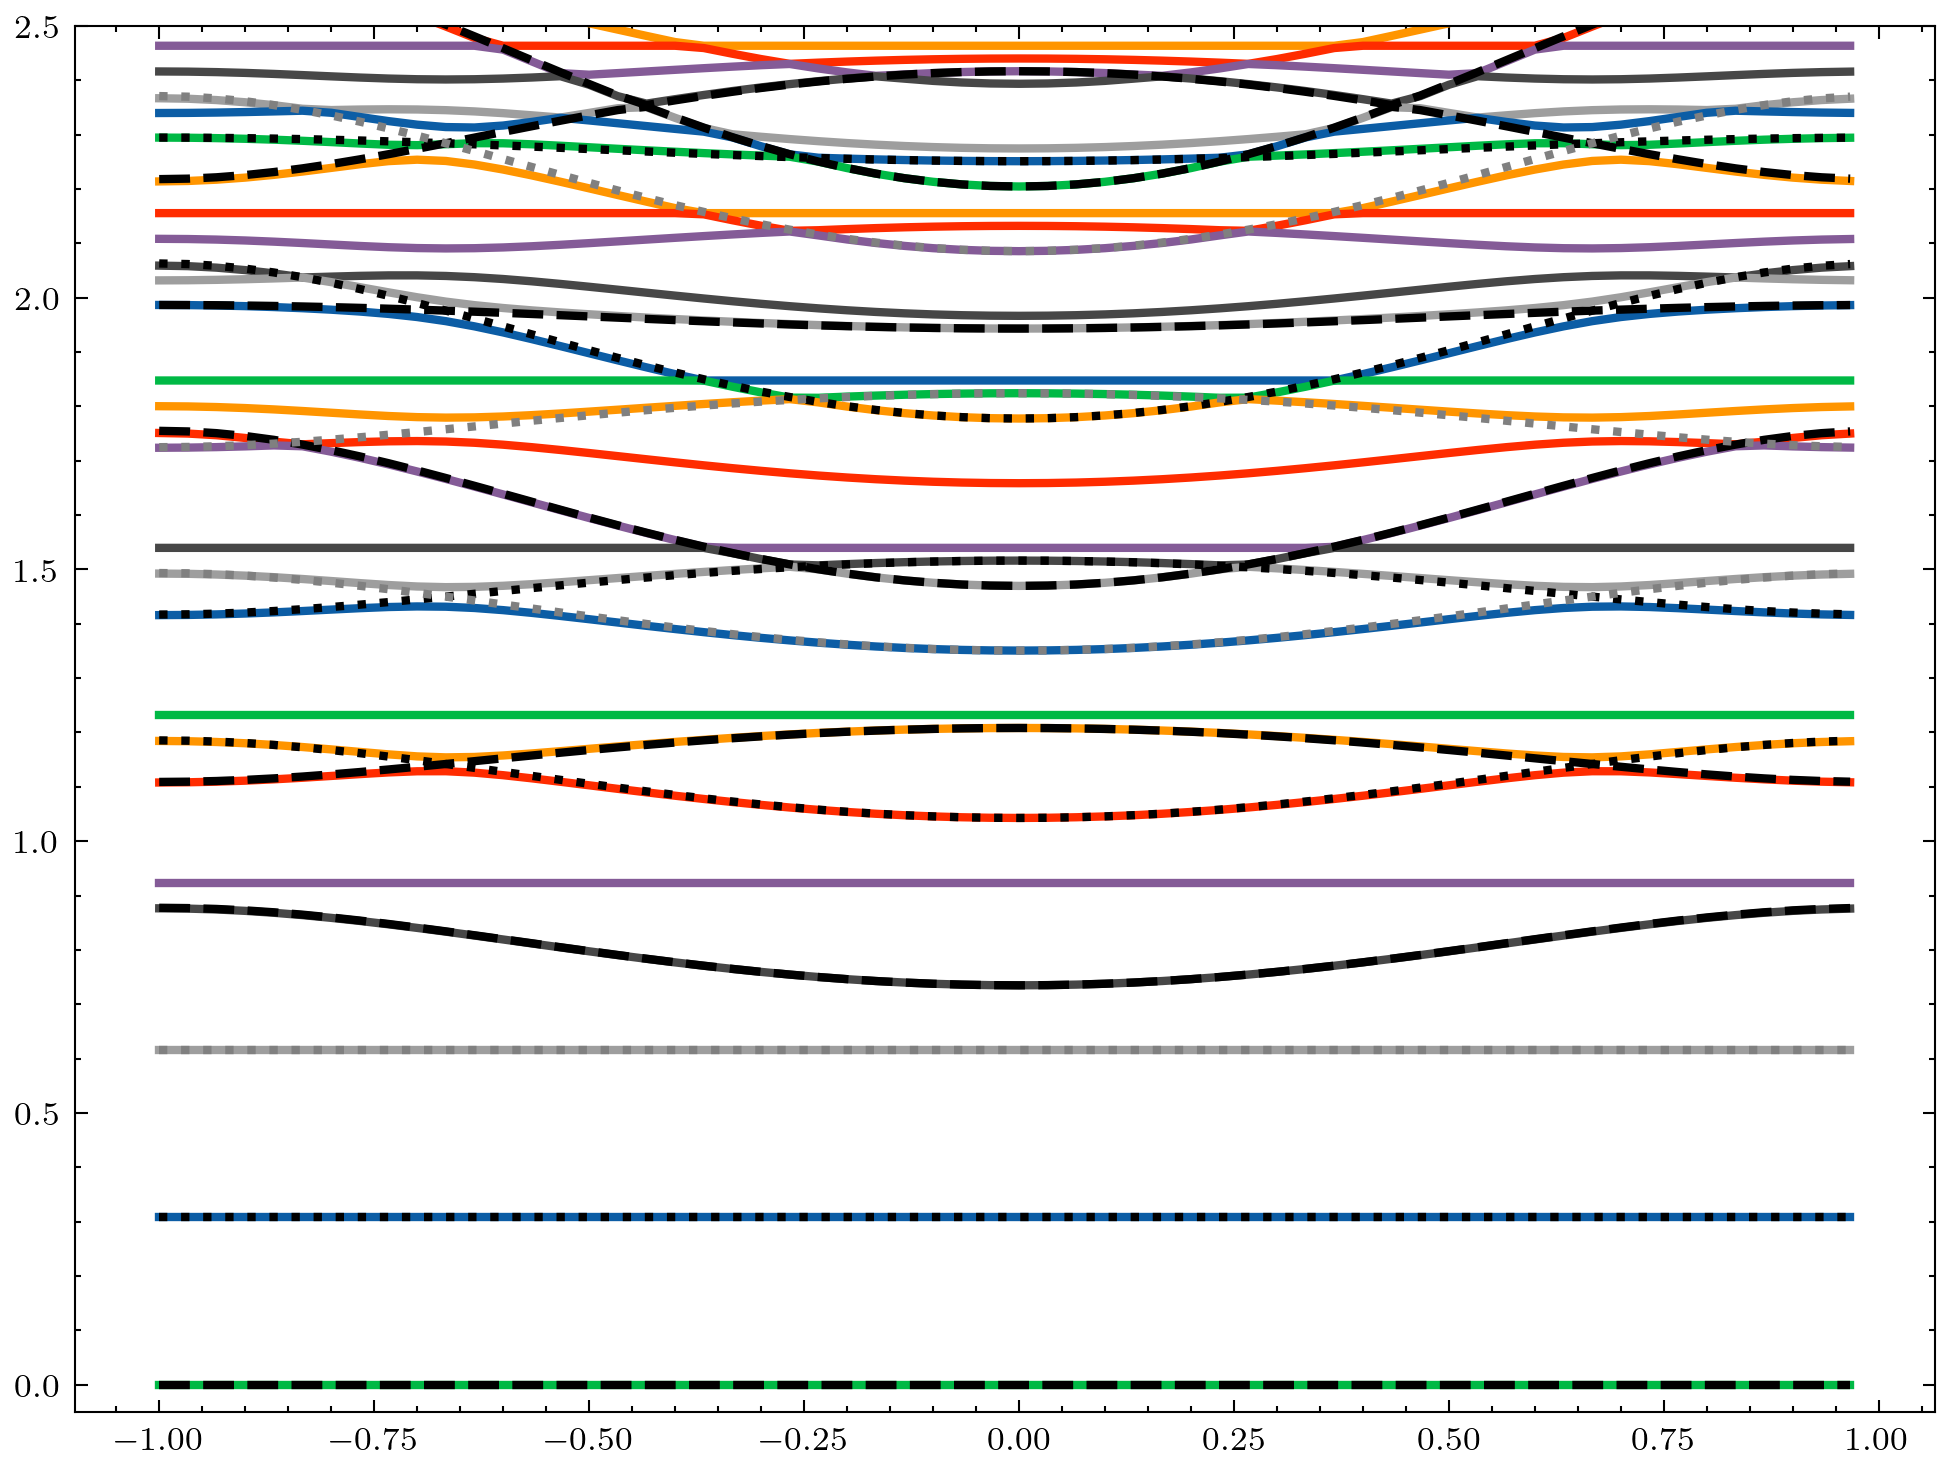

In [24]:
# plt.figure(figsize= (10, 6))
k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
eigenenergies = np.array(eigenenergies)   # shape (N, 10)
energies0     = np.array(energies0)       # shape (N, 10)
# E_ref         = np.min(energies0)

plt.plot(k_values/np.pi, eigenenergies)
plt.plot(k_values/np.pi, energies0, color='black', ls='--')
plt.plot(k_values/np.pi, omega_r + energies0, color='black', ls=':')
plt.plot(k_values/np.pi, 2*omega_r + energies0, color='grey', ls=':')
# plt.plot(k_values/np.pi, 3*omega_r + energies0, color='yellow', ls=':')
plt.ylim(-0.05, 2.5)

In [25]:
def transmon_bands(k_values, Omega_C, chi_C):
    zeta_C = np.sqrt(chi_C**2 + (1-chi_C**2) * np.cos(k_values/2)**2)
    E_alpha = np.sqrt(1 + Omega_C * zeta_C)
    E_beta = np.sqrt(1 - Omega_C * zeta_C)
    
    return E_alpha, E_beta

([<matplotlib.axis.XTick at 0x7053b1a091d0>,
 [Text(-3.141592653589793, 0, '$-\\pi$'),
  Text(-1.5707963267948966, 0, '$-\\frac{\\pi}{2}$'),
  Text(0.0, 0, '0'),
  Text(1.5707963267948966, 0, '$\\frac{\\pi}{2}$'),
  Text(3.141592653589793, 0, '$\\pi$')])

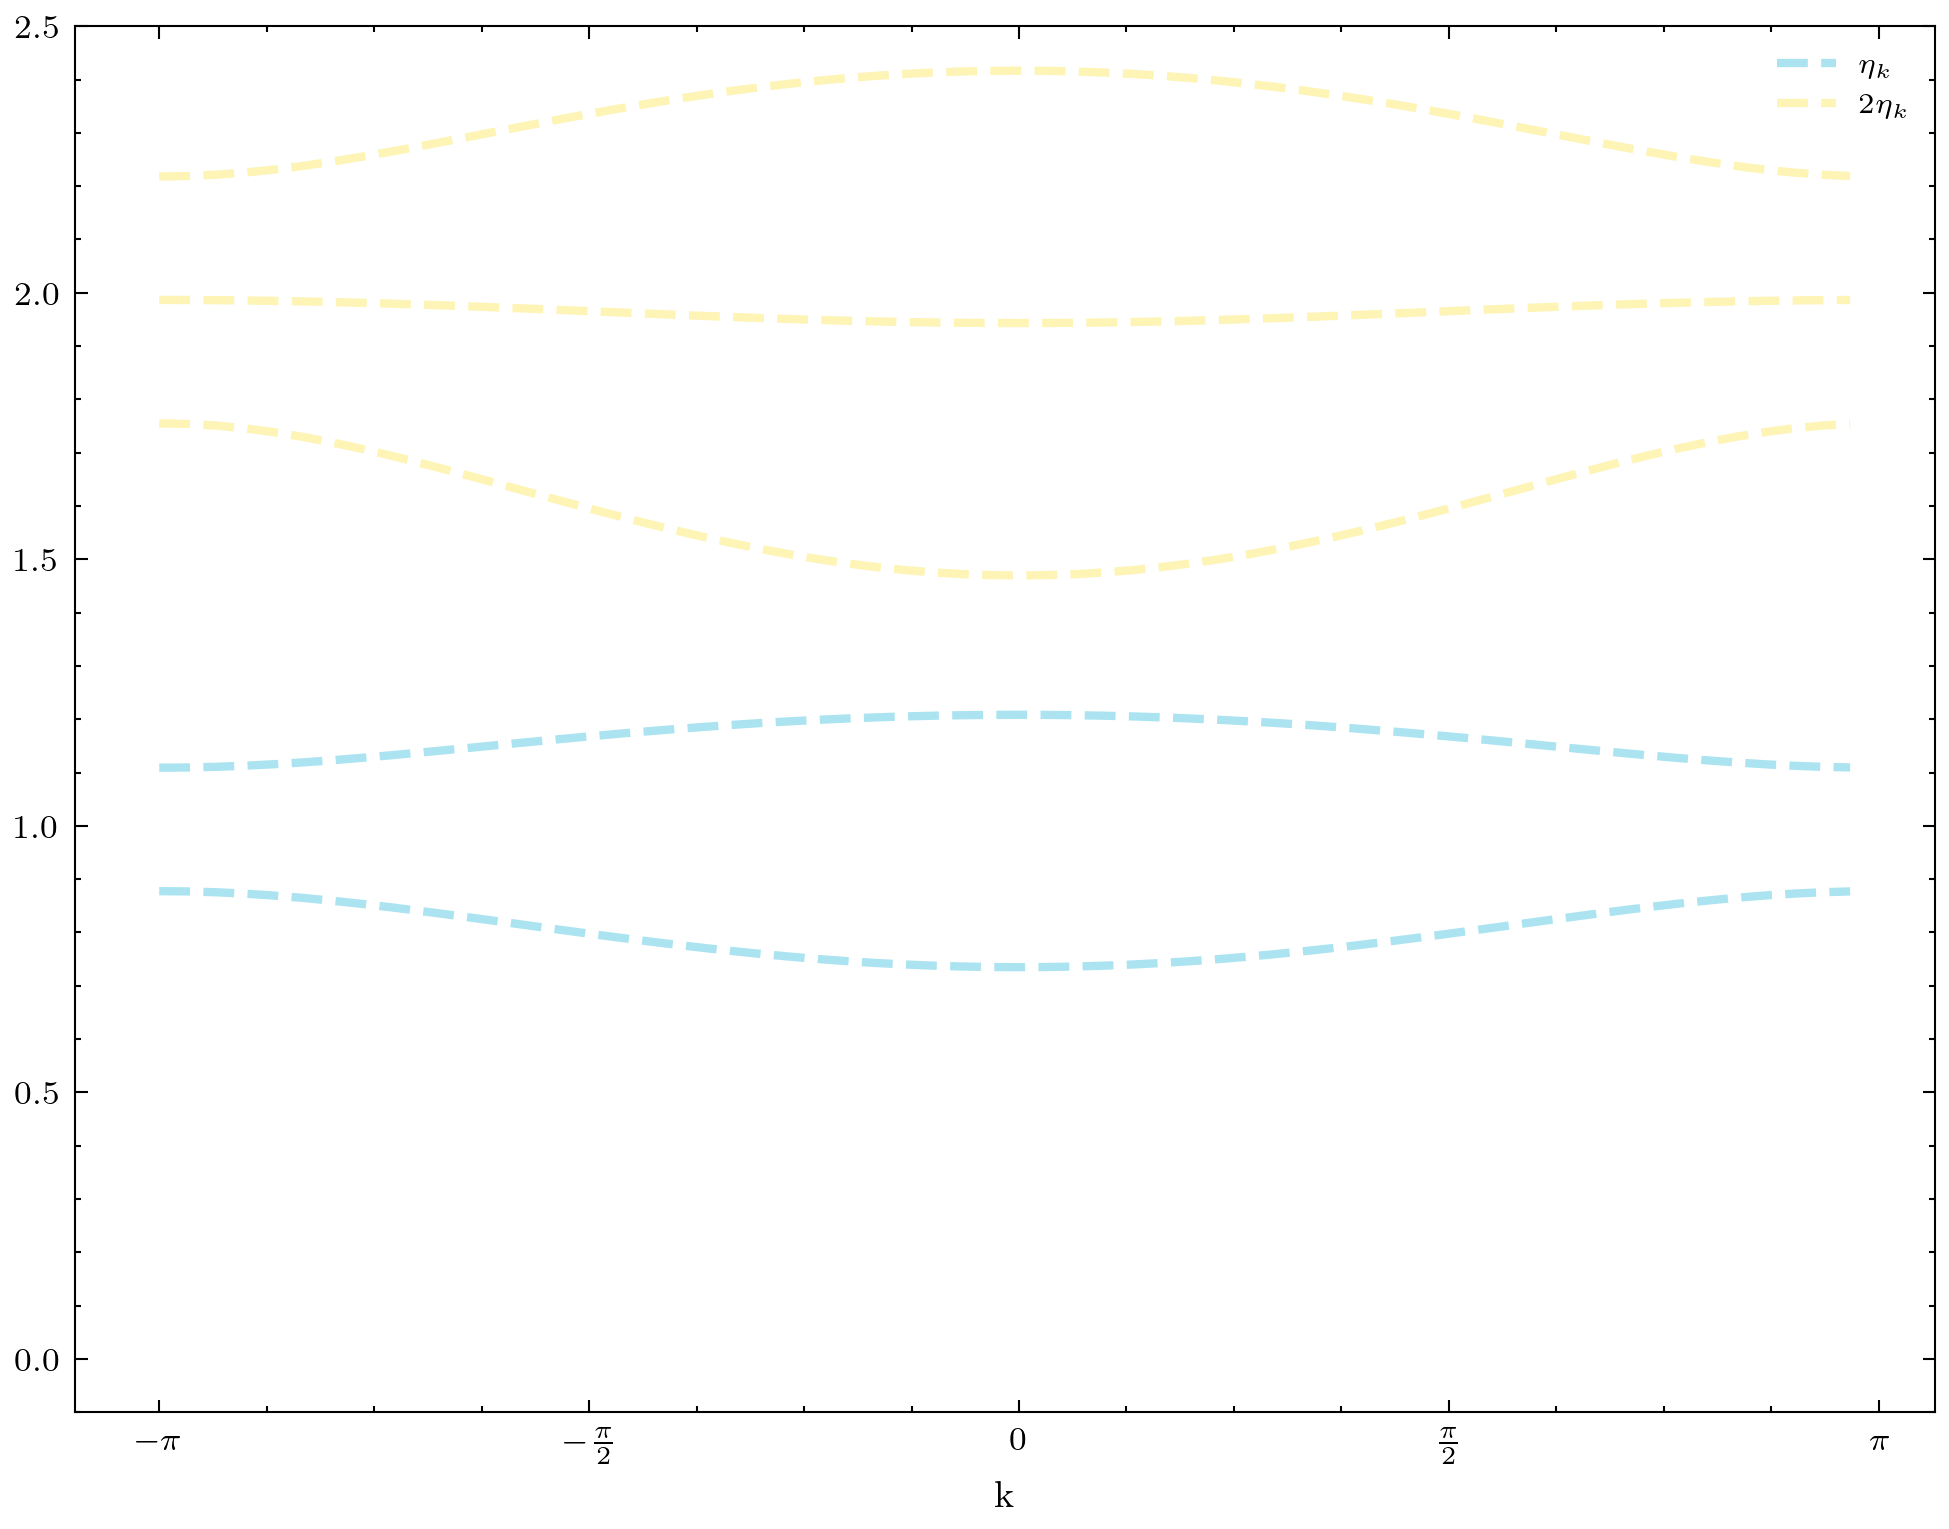

In [28]:
k_values = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/(2*np.pi)))
alpha_energies, beta_energies = transmon_bands(k_values, Omega_C, chi_C)
plt.plot(k_values, alpha_energies, color = '#ABE4F0', linestyle = 'dashed')
plt.plot(k_values, beta_energies, label = r'$\eta_{k}$', color = '#ABE4F0', linestyle = 'dashed')
plt.plot(k_values, 2 * alpha_energies, color = '#FDF4B6', linestyle = 'dashed')
plt.plot(k_values, 2 * beta_energies, color = '#FDF4B6', linestyle = 'dashed')
plt.plot(k_values, alpha_energies + beta_energies, label = r'$2\eta_k$', color = '#FDF4B6', linestyle = 'dashed')
plt.plot(k_values, 3 * alpha_energies, color = '#FDF4B6', linestyle = 'dashed')

plt.legend()
plt.ylim(ymin = -0.1, ymax =  2.5)
plt.xlabel('k')
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi/2, np.pi], [r"$-\pi$", r"$-\frac{\pi}{2}$", "0", r"$\frac{\pi}{2}$", r"$\pi$"])

In [64]:
from scipy.special import gamma
from scipy.special import gamma

def squeezed_probability(Omega_C, n):
    cosh_2r = 1.0 / np.sqrt(1 - Omega_C)
    tanh_r = np.sqrt((cosh_2r - 1) / (cosh_2r + 1))
    cosh_r = np.sqrt((cosh_2r + 1) / 2)
    return tanh_r**(2*n) * gamma(2*n + 1) / (cosh_r * gamma(n + 1)**2 * 4**n)

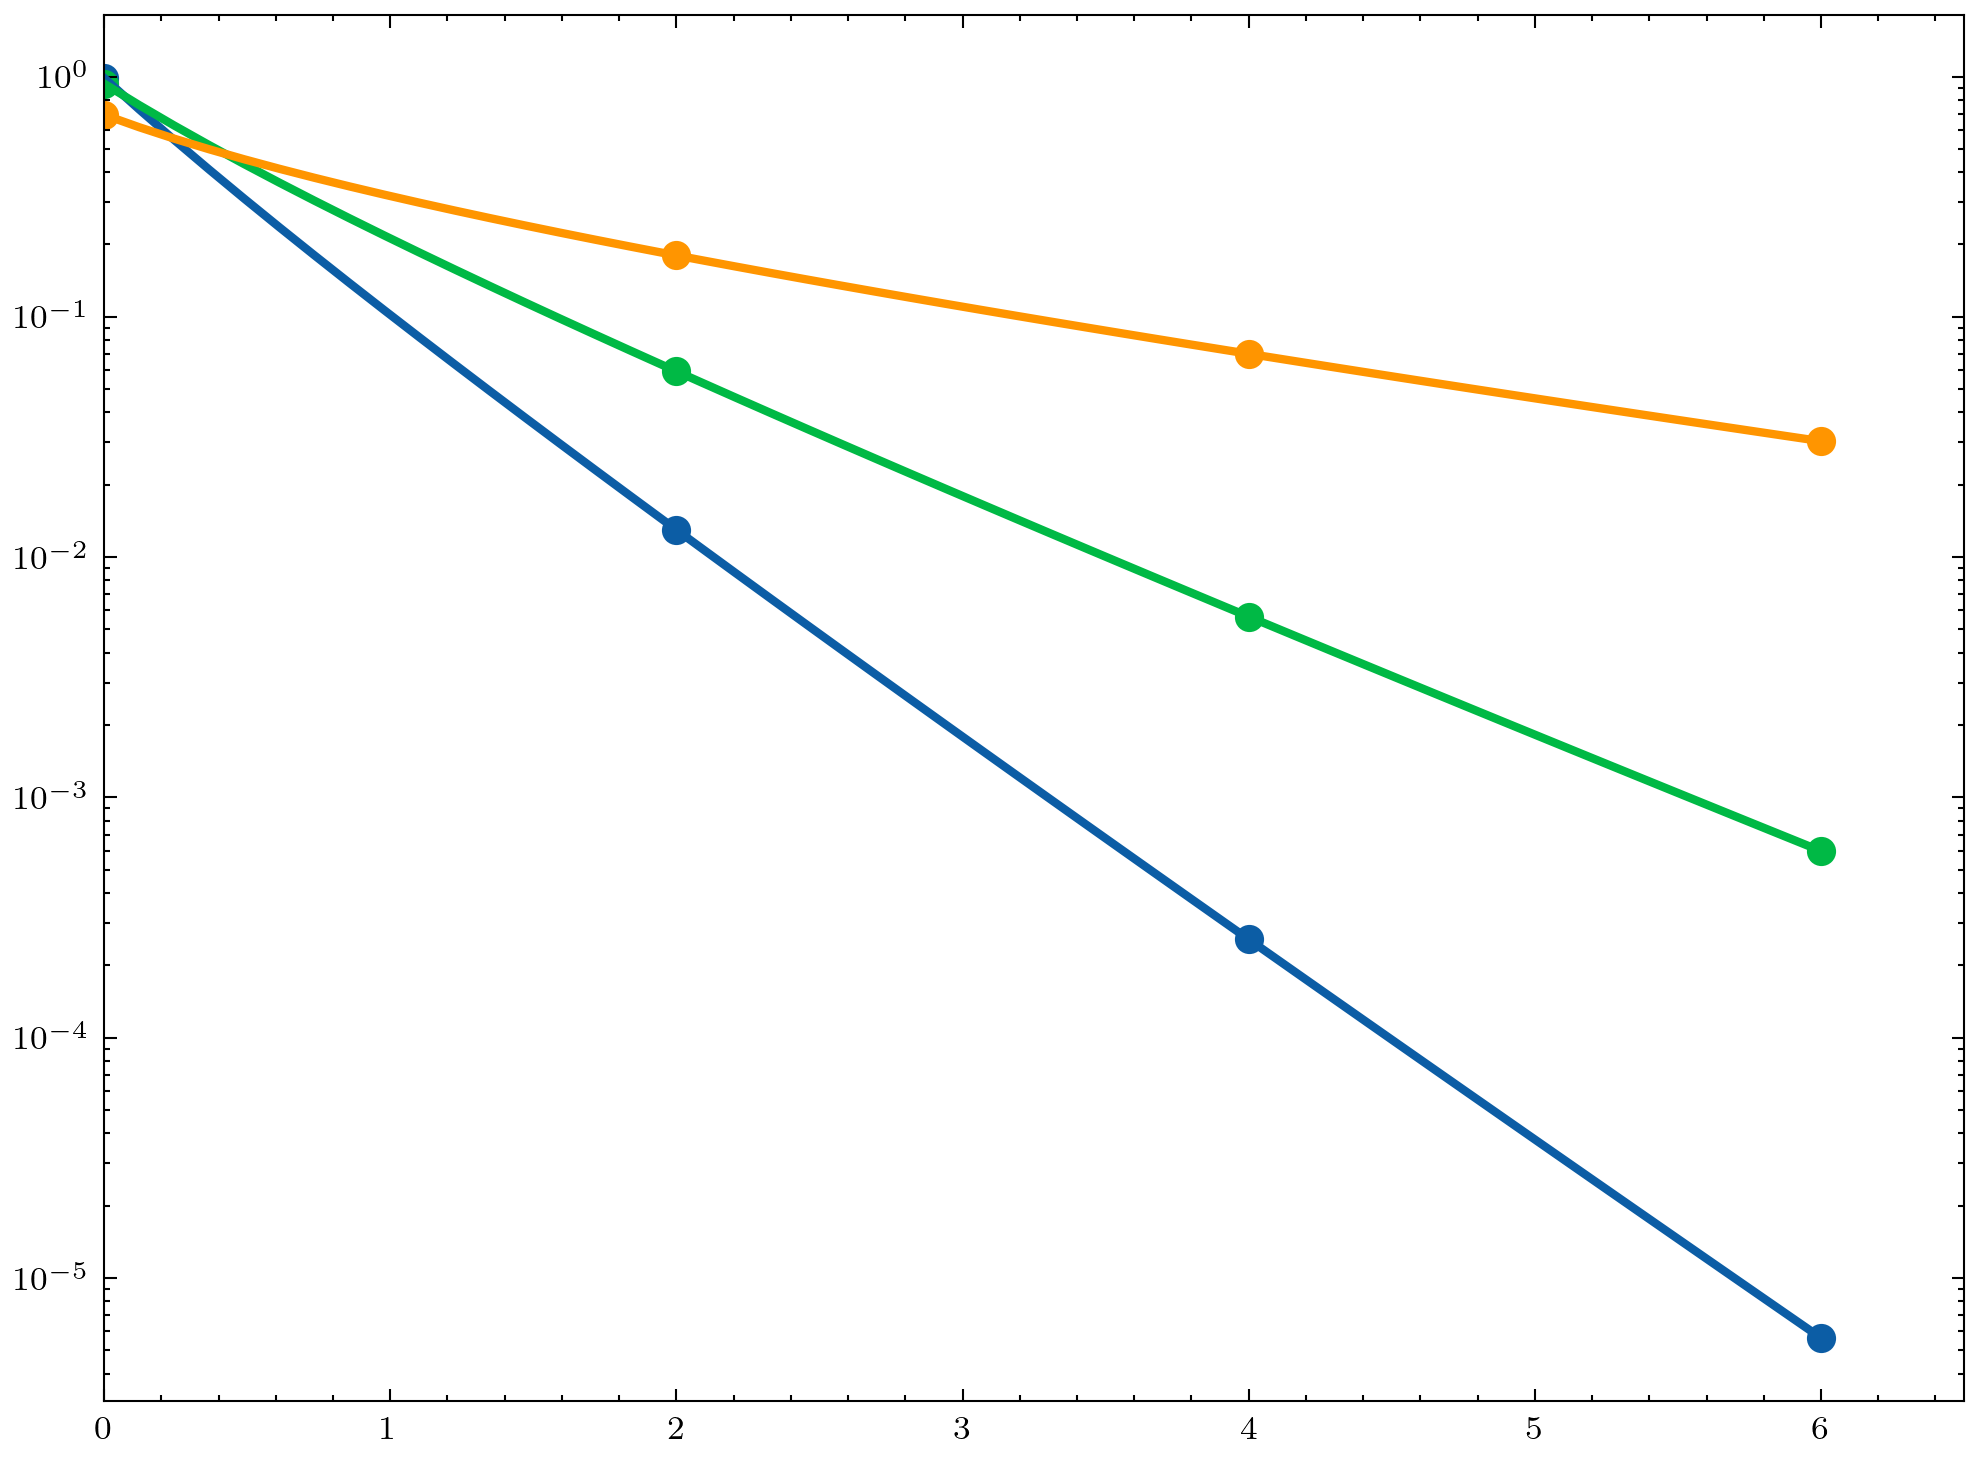

In [65]:
N = 3
Omega_C_1 = 0.1
Omega_C_2 = 0.4
Omega_C_3 = 0.9
n = np.linspace(0.0, N)
n_integer = np.linspace(0, N, N+1)
plt.yscale('log')
plt.xlim(0.0, 6.5)
plt.plot(2 * n, squeezed_probability(Omega_C_1, n))
plt.scatter(2 * n_integer, squeezed_probability(Omega_C_1, n_integer))
plt.plot(2 * n, squeezed_probability(Omega_C_2, n))
plt.scatter(2 * n_integer, squeezed_probability(Omega_C_2, n_integer))
plt.plot(2 * n, squeezed_probability(Omega_C_3, n))
plt.scatter(2 * n_integer, squeezed_probability(Omega_C_3, n_integer))

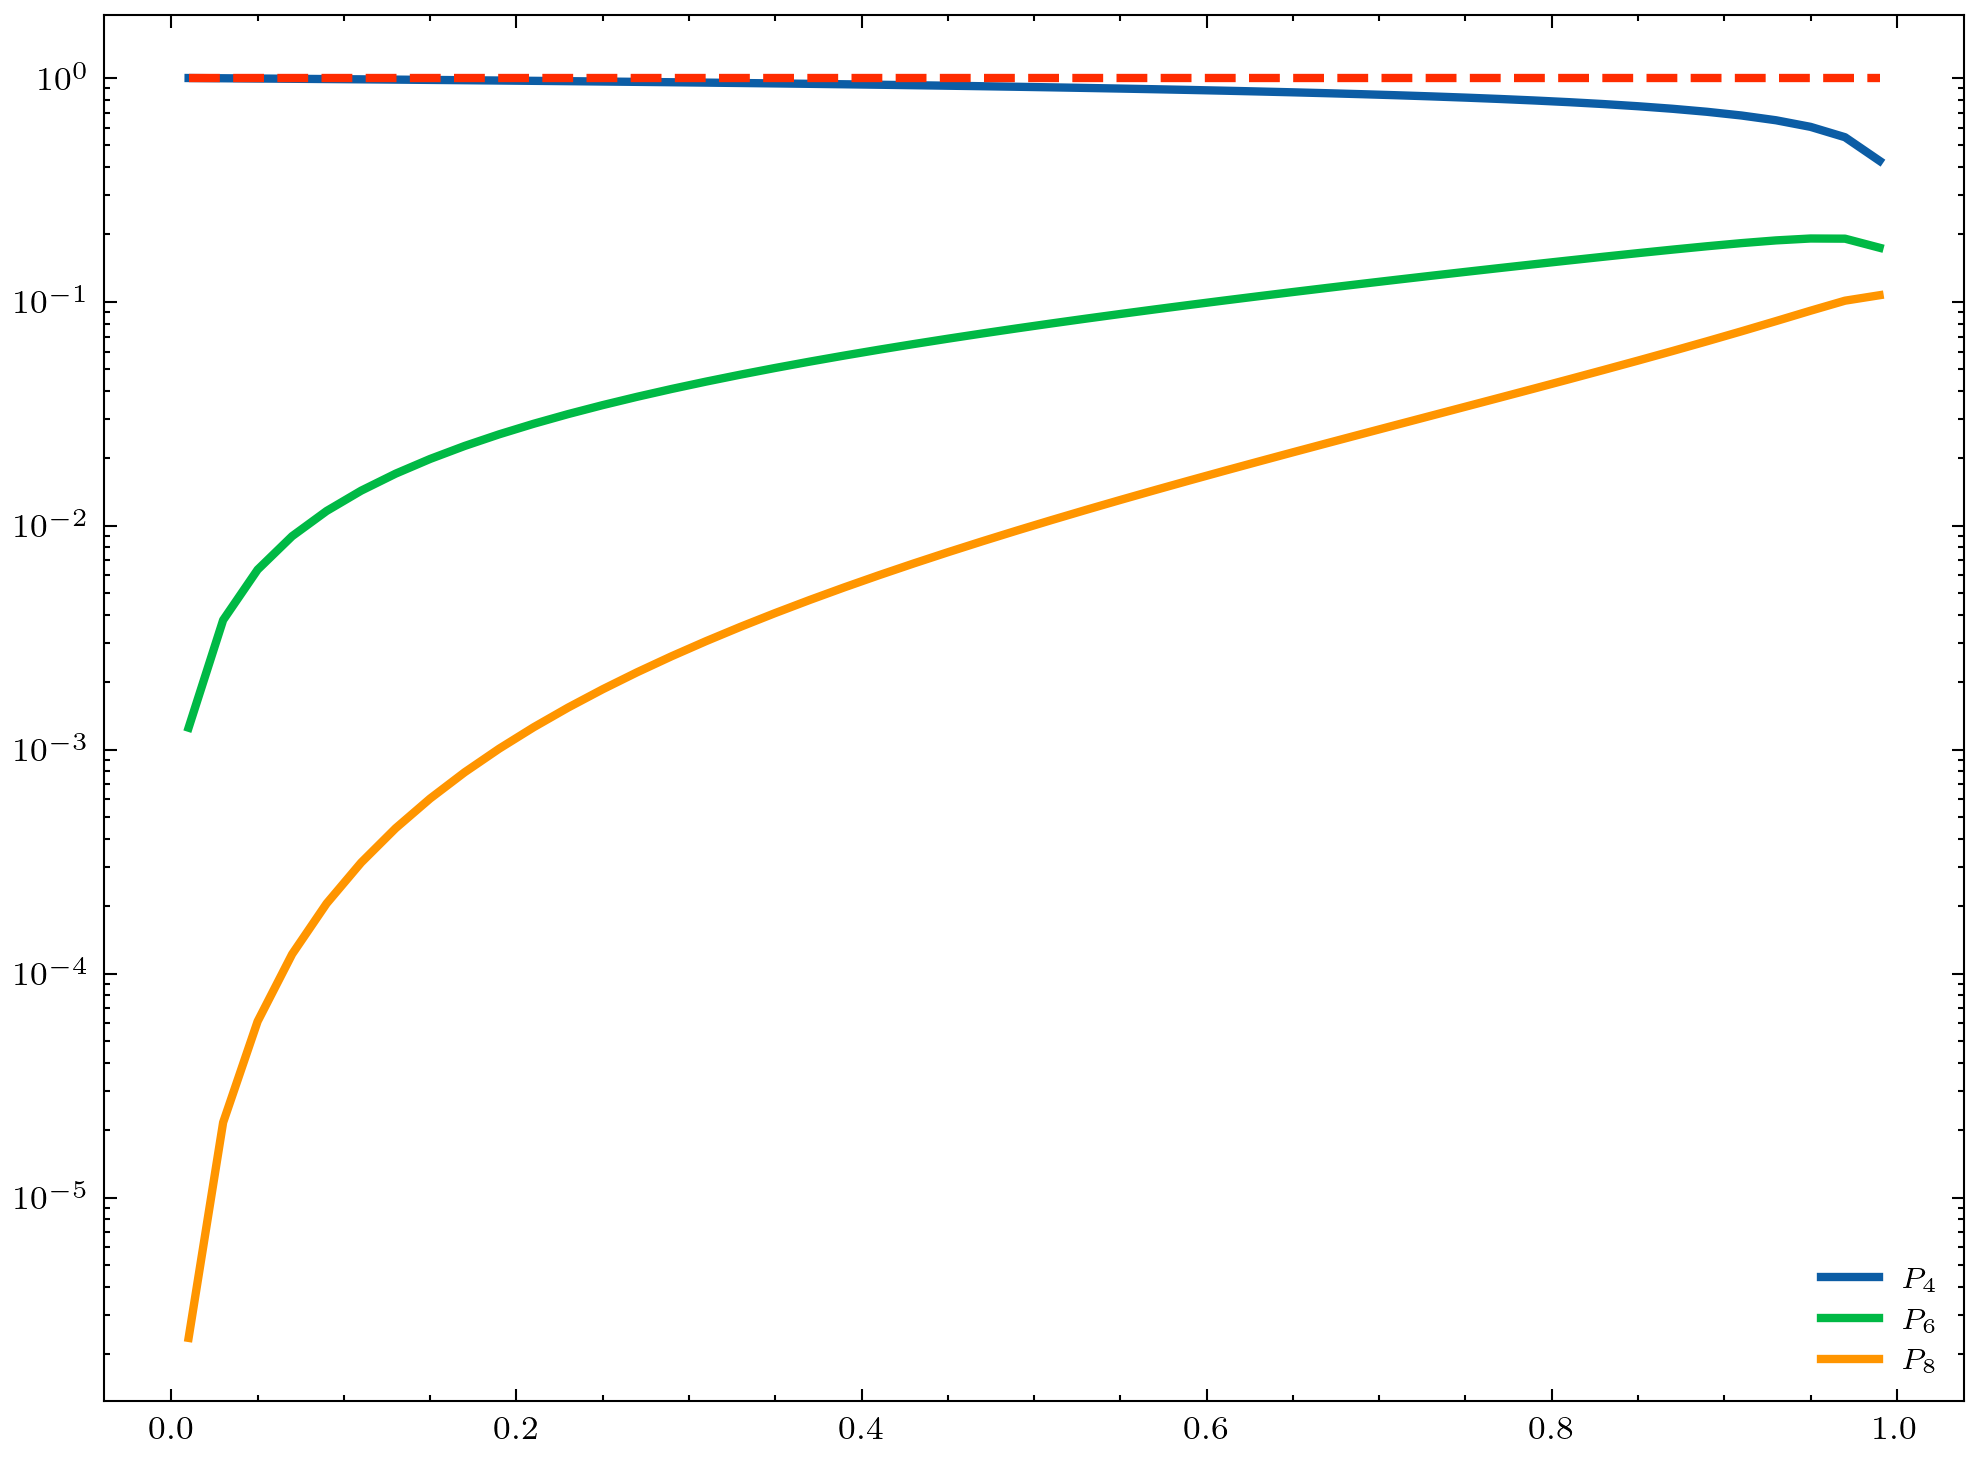

In [66]:
Omega_C_values = np.linspace(0.01, 0.99)
p4 = squeezed_probability(Omega_C_values, 0)
p6 = squeezed_probability(Omega_C_values, 1)
p8 = squeezed_probability(Omega_C_values, 2)

plt.plot(Omega_C_values, p4, label = r'$P_4$')
plt.plot(Omega_C_values, p6, label = r'$P_6$')
plt.plot(Omega_C_values, p8, label = r'$P_8$')

plt.plot(Omega_C_values, np.ones_like(Omega_C_values), linestyle = 'dashed')

plt.yscale('log')
# plt.xscale('log')
plt.legend()

In [67]:
import qutip as qt
import numpy as np

def squeezed_excited_probability(r, phi, m, n_levels=50):
    """
    Photon number distribution for squeezed Fock state S(r,phi)|m>.
    Returns array of P(n) for n = 0, ..., n_levels-1.
    """
    xi = r * np.exp(1j * phi)
    fock_m = qt.fock(n_levels, m)
    squeezed_state = qt.squeeze(n_levels, xi) * fock_m
    return np.abs(squeezed_state.full().flatten())**2

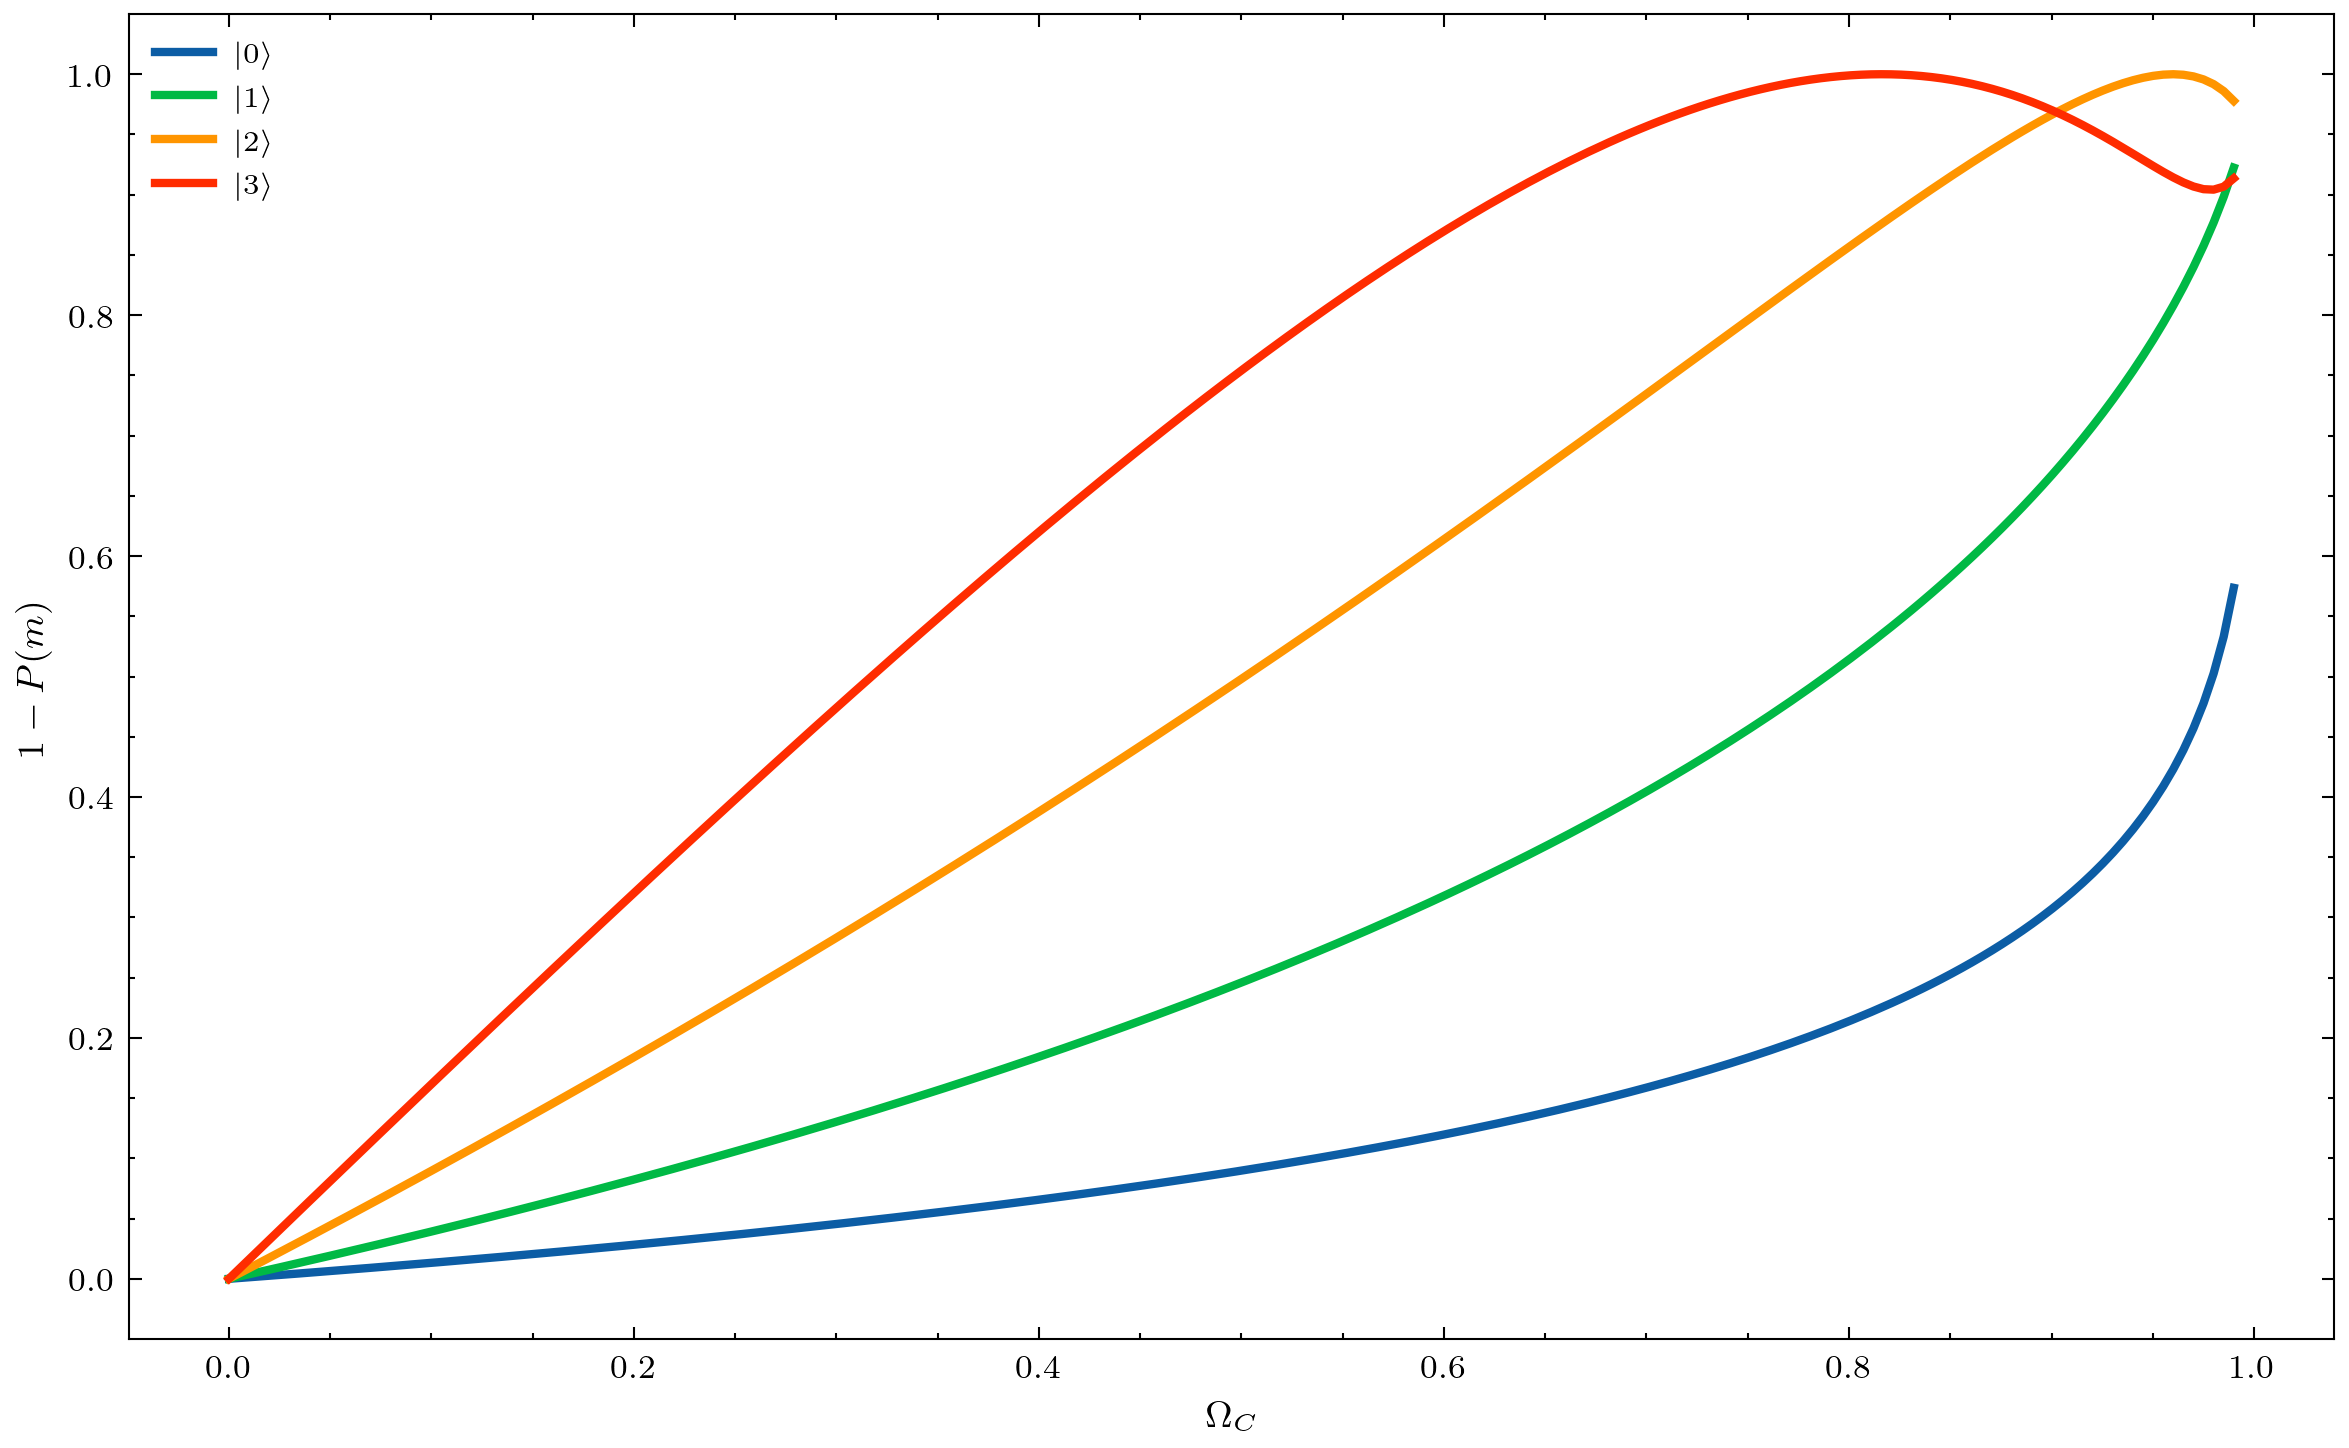

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

Omega_C_values = np.linspace(0, 0.99, 200)
n_levels = 30

r_values = np.arccosh(1.0 / np.sqrt(1 - Omega_C_values)) / 2

fig, ax = plt.subplots(figsize=(8, 5))

for m in [0, 1, 2, 3]:
    pm = []
    for r in r_values:
        xi = r * np.exp(1j * 0.0)
        state = qt.squeeze(n_levels, xi) * qt.fock(n_levels, m)
        probs = np.abs(state.full().flatten())**2
        pm.append(probs[m])

    ax.plot(Omega_C_values, 1 - np.array(pm), label=f'$|{m}\\rangle$')

ax.set_xlabel(r'$\Omega_C$')
ax.set_ylabel(r'$1 - P(m)$')
ax.legend()
plt.tight_layout()
plt.show()

In [103]:
from scipy.special import gammaln
import numpy as np

def squeeze_matrix_element(r, m, n):
    if (n % 2) != (m % 2):
        return 0.0
    
    prefactor = np.exp(0.5 * (gammaln(m + 1) + gammaln(n + 1) - np.log(np.cosh(r))))
    
    k_min = max(0, (m - n) // 2)
    k_max = m // 2
    
    summation = 0.0
    for k in range(k_min, k_max + 1):
        index = k + (n - m) // 2
        sign = (-1) ** (k + (n - m) // 2)
        term = (np.tanh(r) / 2)**index * (1 / np.cosh(r))**(m - 2*k)
        term /= np.exp(gammaln(k + 1) + gammaln(index + 1) + gammaln(m - 2*k + 1))
        summation += sign * term
    
    return prefactor * summation

r_threshold = np.log(1e3)

def log_squeeze_matrix_element_sq(r, m, n):
    """Returns log(|<n|S(r)|m>|^2), i.e. log of the probability."""
    if (n % 2) != (m % 2):
        return -np.inf

    k_min = max(0, (m - n) // 2)
    k_max = m // 2

    log_prefactor = 0.5 * (gammaln(m + 1) + gammaln(n + 1) - np.log(np.cosh(r)))

    summation = 0.0
    for k in range(k_min, k_max + 1):
        index = k + (n - m) // 2
        sign = (-1) ** (k + (n - m) // 2)

        if r >= r_threshold:
            # tanh(r) -> 1, cosh(r) -> exp(r)/2
            term = (1.0 / 2)**index * (2.0 / np.exp(r))**(m - 2*k)
        else:
            term = (np.tanh(r) / 2)**index * (1.0 / np.cosh(r))**(m - 2*k)

        term /= np.exp(gammaln(k + 1) + gammaln(index + 1) + gammaln(m - 2*k + 1))
        summation += sign * term

    if summation == 0.0:
        return -np.inf

    return 2 * (log_prefactor + np.log(np.abs(summation)))

In [ ]:
from scipy.special import gammaln, lpmv
import numpy as np

def squeeze_matrix_element_legendre(r, m, n):

    if (m - n) % 2 != 0:
        return 0.0

    x = 1.0 / np.cosh(r)
    l = (m + n) / 2  # half-integer in general, but integer when m+n even
    n_less = min(m, n)
    n_greater = max(m, n)

    log_prefactor = 0.5 * (gammaln(n_less + 1) - gammaln(n_greater + 1))

    if m >= n:
        # Eq. (8): k = (m-n)/2
        k = (m - n) // 2
        sign = (-1) ** k
        P = lpmv(k, l, x)
        return sign * np.exp(log_prefactor) * np.sqrt(x) * P

    else:
        # Eq. (9): k' = (n-m)/2
        k = (n - m) // 2
        P = lpmv(k, l, x)
        return np.exp(log_prefactor) * np.sqrt(x) * P
    

def log_squeeze_matrix_element_legendre_sqr(r, m, n):
    """
    Matrix element <m|S(r)|n> using associated Legendre function formula.
    Real squeeze parameter r (xi = r, phi = 0).
    Eqs. (8)-(9) from the reference.
    """
    if (m - n) % 2 != 0:
        return 0.0

    x = 1.0 / np.cosh(r)
    l = (m + n) / 2  # half-integer in general, but integer when m+n even
    n_less = min(m, n)
    n_greater = max(m, n)

    log_prefactor = 0.5 * (gammaln(n_less + 1) - gammaln(n_greater + 1))

    if m >= n:
        # Eq. (8): k = (m-n)/2
        k = (m - n) // 2
        sign = (-1) ** k
        P = lpmv(k, l, x)
        return 2 * log_prefactor + x +  2 * P

    else:
        # Eq. (9): k' = (n-m)/2
        k = (n - m) // 2
        P = lpmv(k, l, x)
        return 2 * log_prefactor + x +  2 * P

/tmp/ipykernel_825263/3969143779.py:3: RuntimeWarning: divide by zero encountered in log
  squeeze_matrix = np.array([[np.log(squeeze_matrix_element_legendre(r, j, i)**2) for j in range(N)] for i in range(N)])


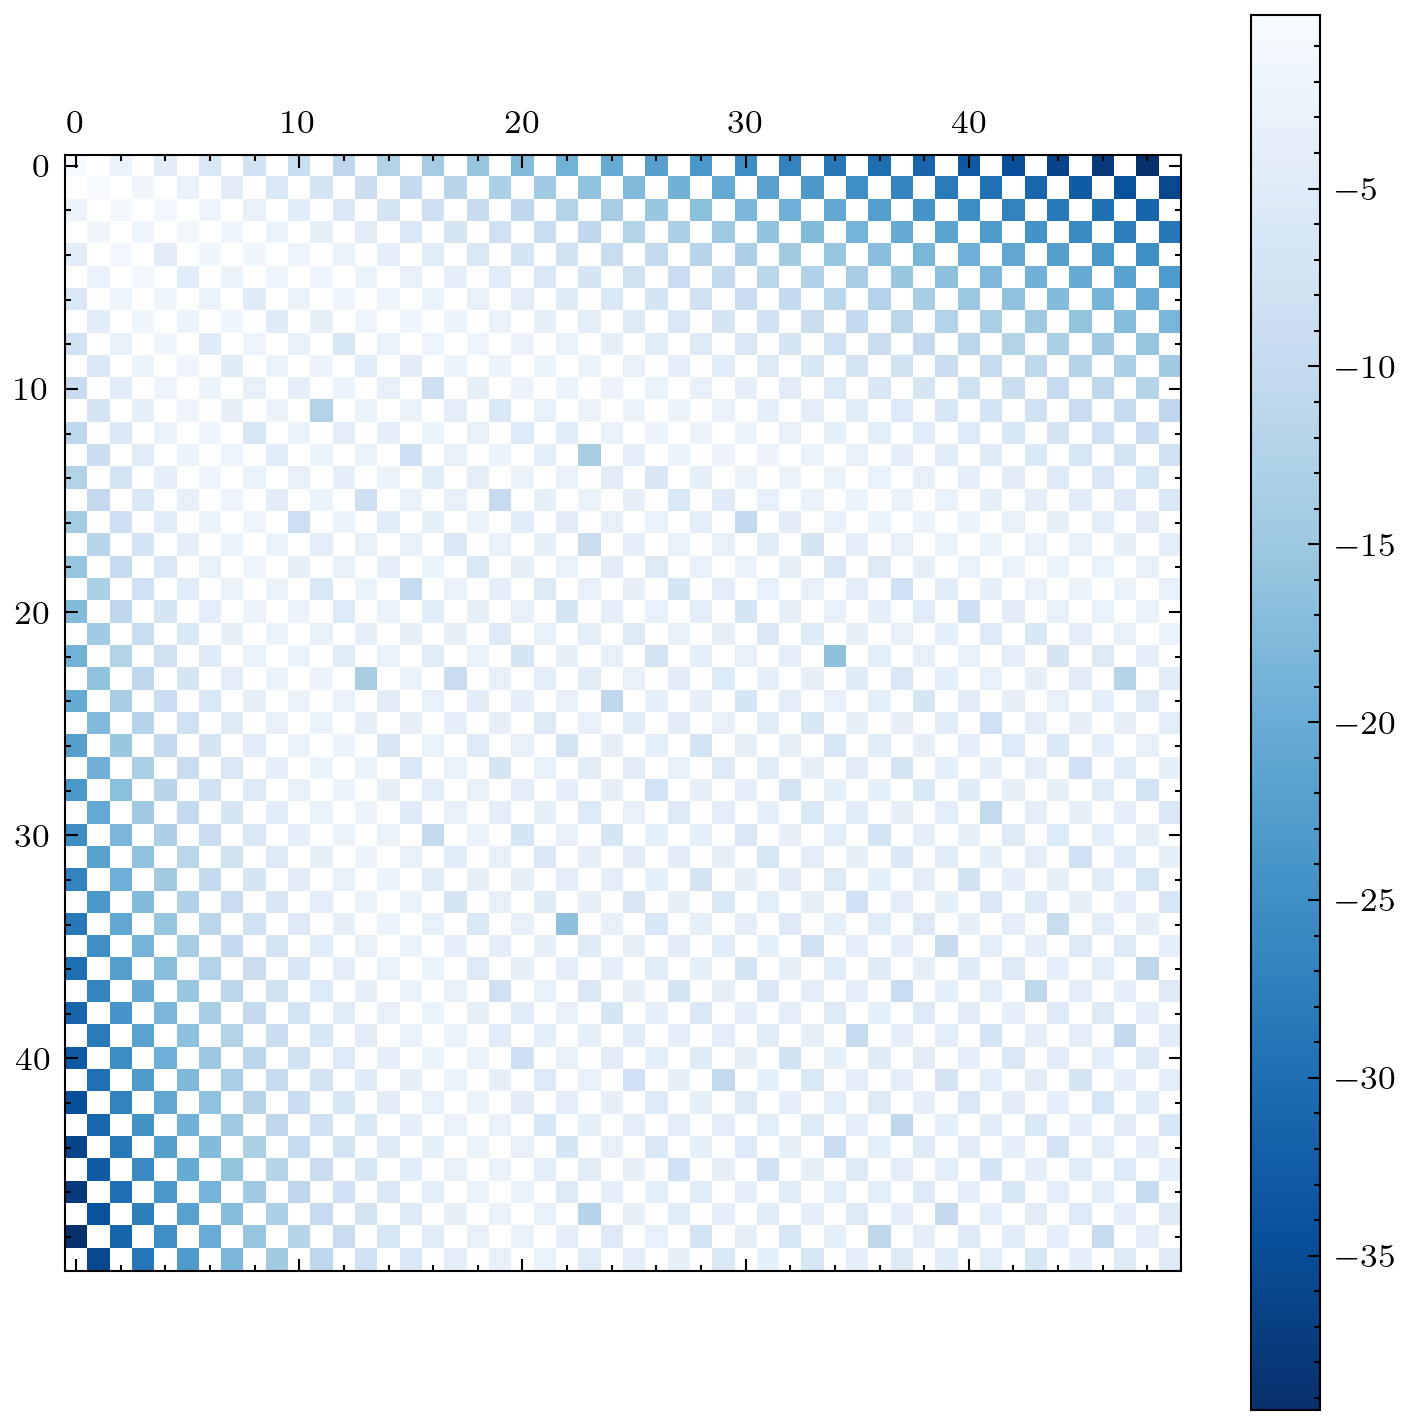

In [139]:
N = 50
r = 0.5
squeeze_matrix = np.array([[np.log(squeeze_matrix_element_legendre(r, j, i)**2) for j in range(N)] for i in range(N)])

# Replace -inf (forbidden) with NaN so they show as white
squeeze_matrix[np.isinf(squeeze_matrix)] = np.nan

# Now all valid entries are <= 0, so no symmetry needed
fig = plt.matshow(squeeze_matrix, cmap='Blues_r')
plt.colorbar(fig)
plt.show()

In [197]:
def minimum_n(Omega_C, n, threshold = 0.95, N = 60):
    r = -0.25 * np.log(1-Omega_C)
    prob_array = [squeeze_matrix_element_legendre(r, i, n)**2 for i in range(N)]
    sum = 0.0 
    for j, prob in enumerate(prob_array):
        sum += prob
        if sum >= threshold:
            return j+1
    
    return N

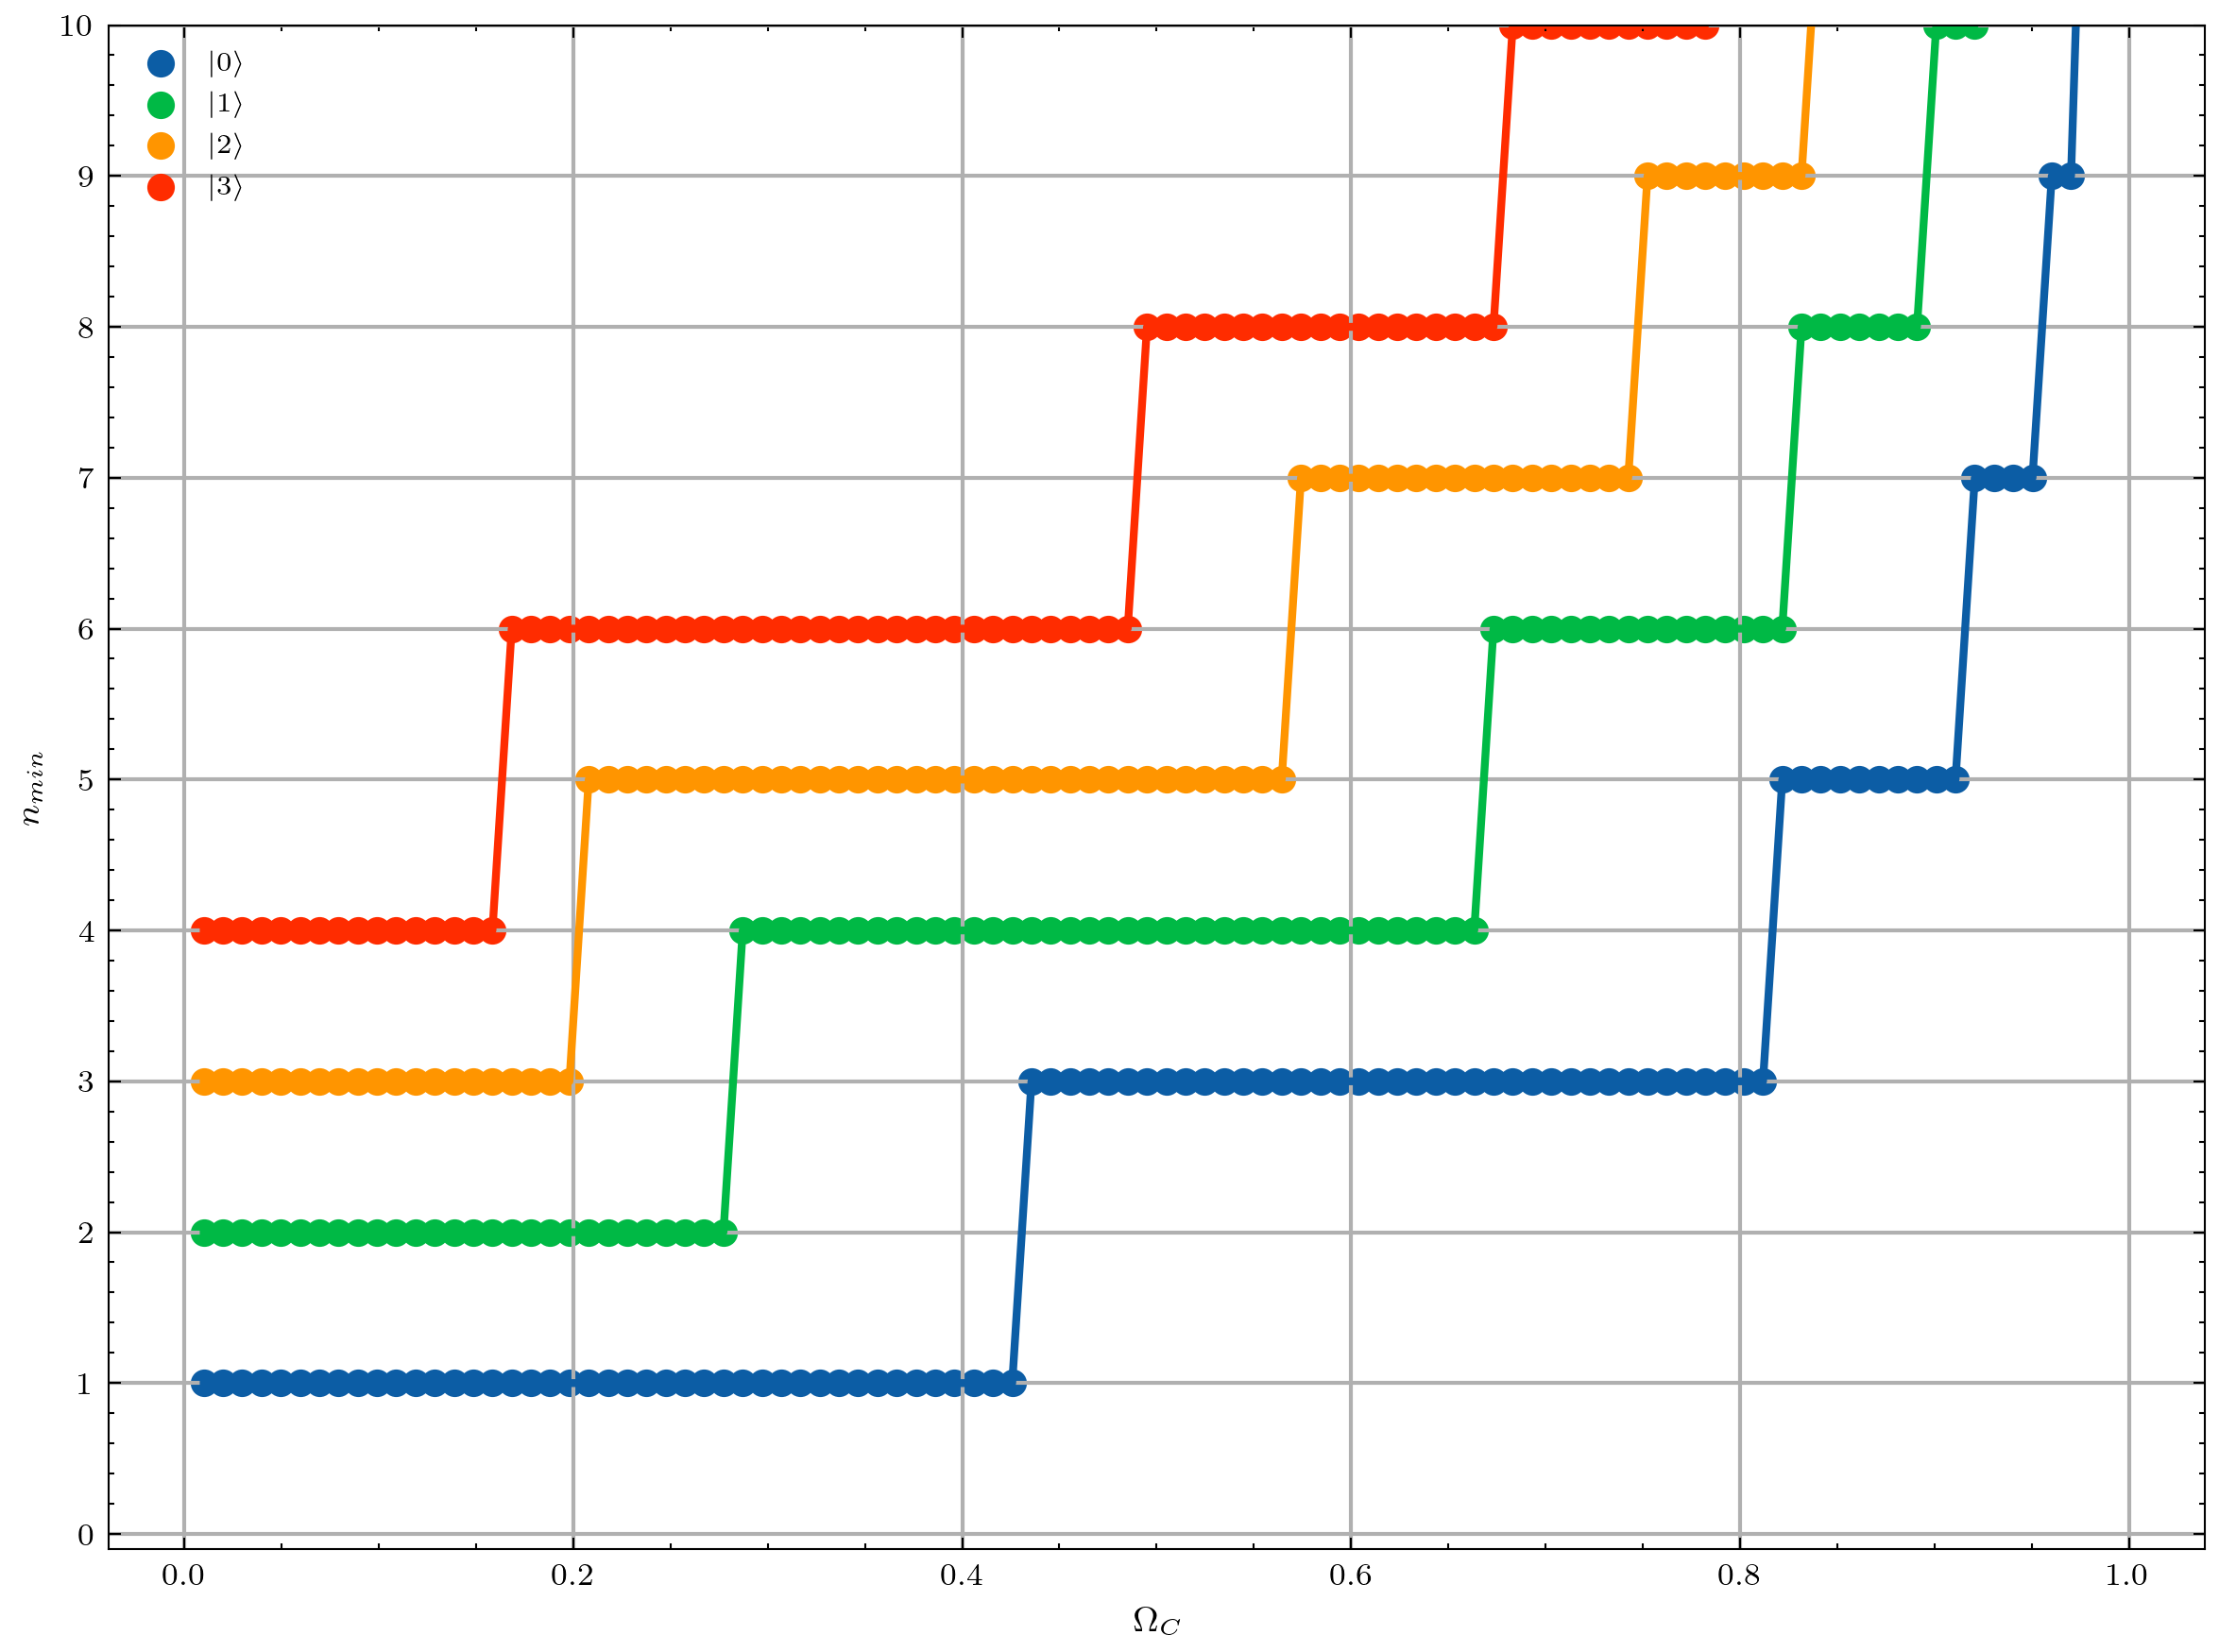

In [209]:
Omega_C_values = np.linspace(0.01, 0.99, 100)
minimum_n_values = [minimum_n(Omega_C, 0, 0.99) for Omega_C in Omega_C_values]
plt.plot(Omega_C_values, minimum_n_values)
plt.scatter(Omega_C_values, minimum_n_values, label = r'$\vert 0 \rangle$')

minimum_n_values = [minimum_n(Omega_C, 1, 0.99) for Omega_C in Omega_C_values]
plt.plot(Omega_C_values, minimum_n_values)
plt.scatter(Omega_C_values, minimum_n_values, label = r'$\vert 1 \rangle$')

minimum_n_values = [minimum_n(Omega_C, 2, 0.99) for Omega_C in Omega_C_values]
plt.plot(Omega_C_values, minimum_n_values)
plt.scatter(Omega_C_values, minimum_n_values, label = r'$\vert 2 \rangle$')

minimum_n_values = [minimum_n(Omega_C, 3, 0.99) for Omega_C in Omega_C_values]
plt.plot(Omega_C_values, minimum_n_values)
plt.scatter(Omega_C_values, minimum_n_values, label = r'$\vert 3 \rangle$')

plt.ylim(-0.1, 10)
plt.yticks(np.arange(0,11,1, dtype = int))
plt.grid(True)
plt.xlabel(r'$\Omega_C$')
plt.ylabel(r'$n_{min}$')
plt.legend()
plt.tight_layout()

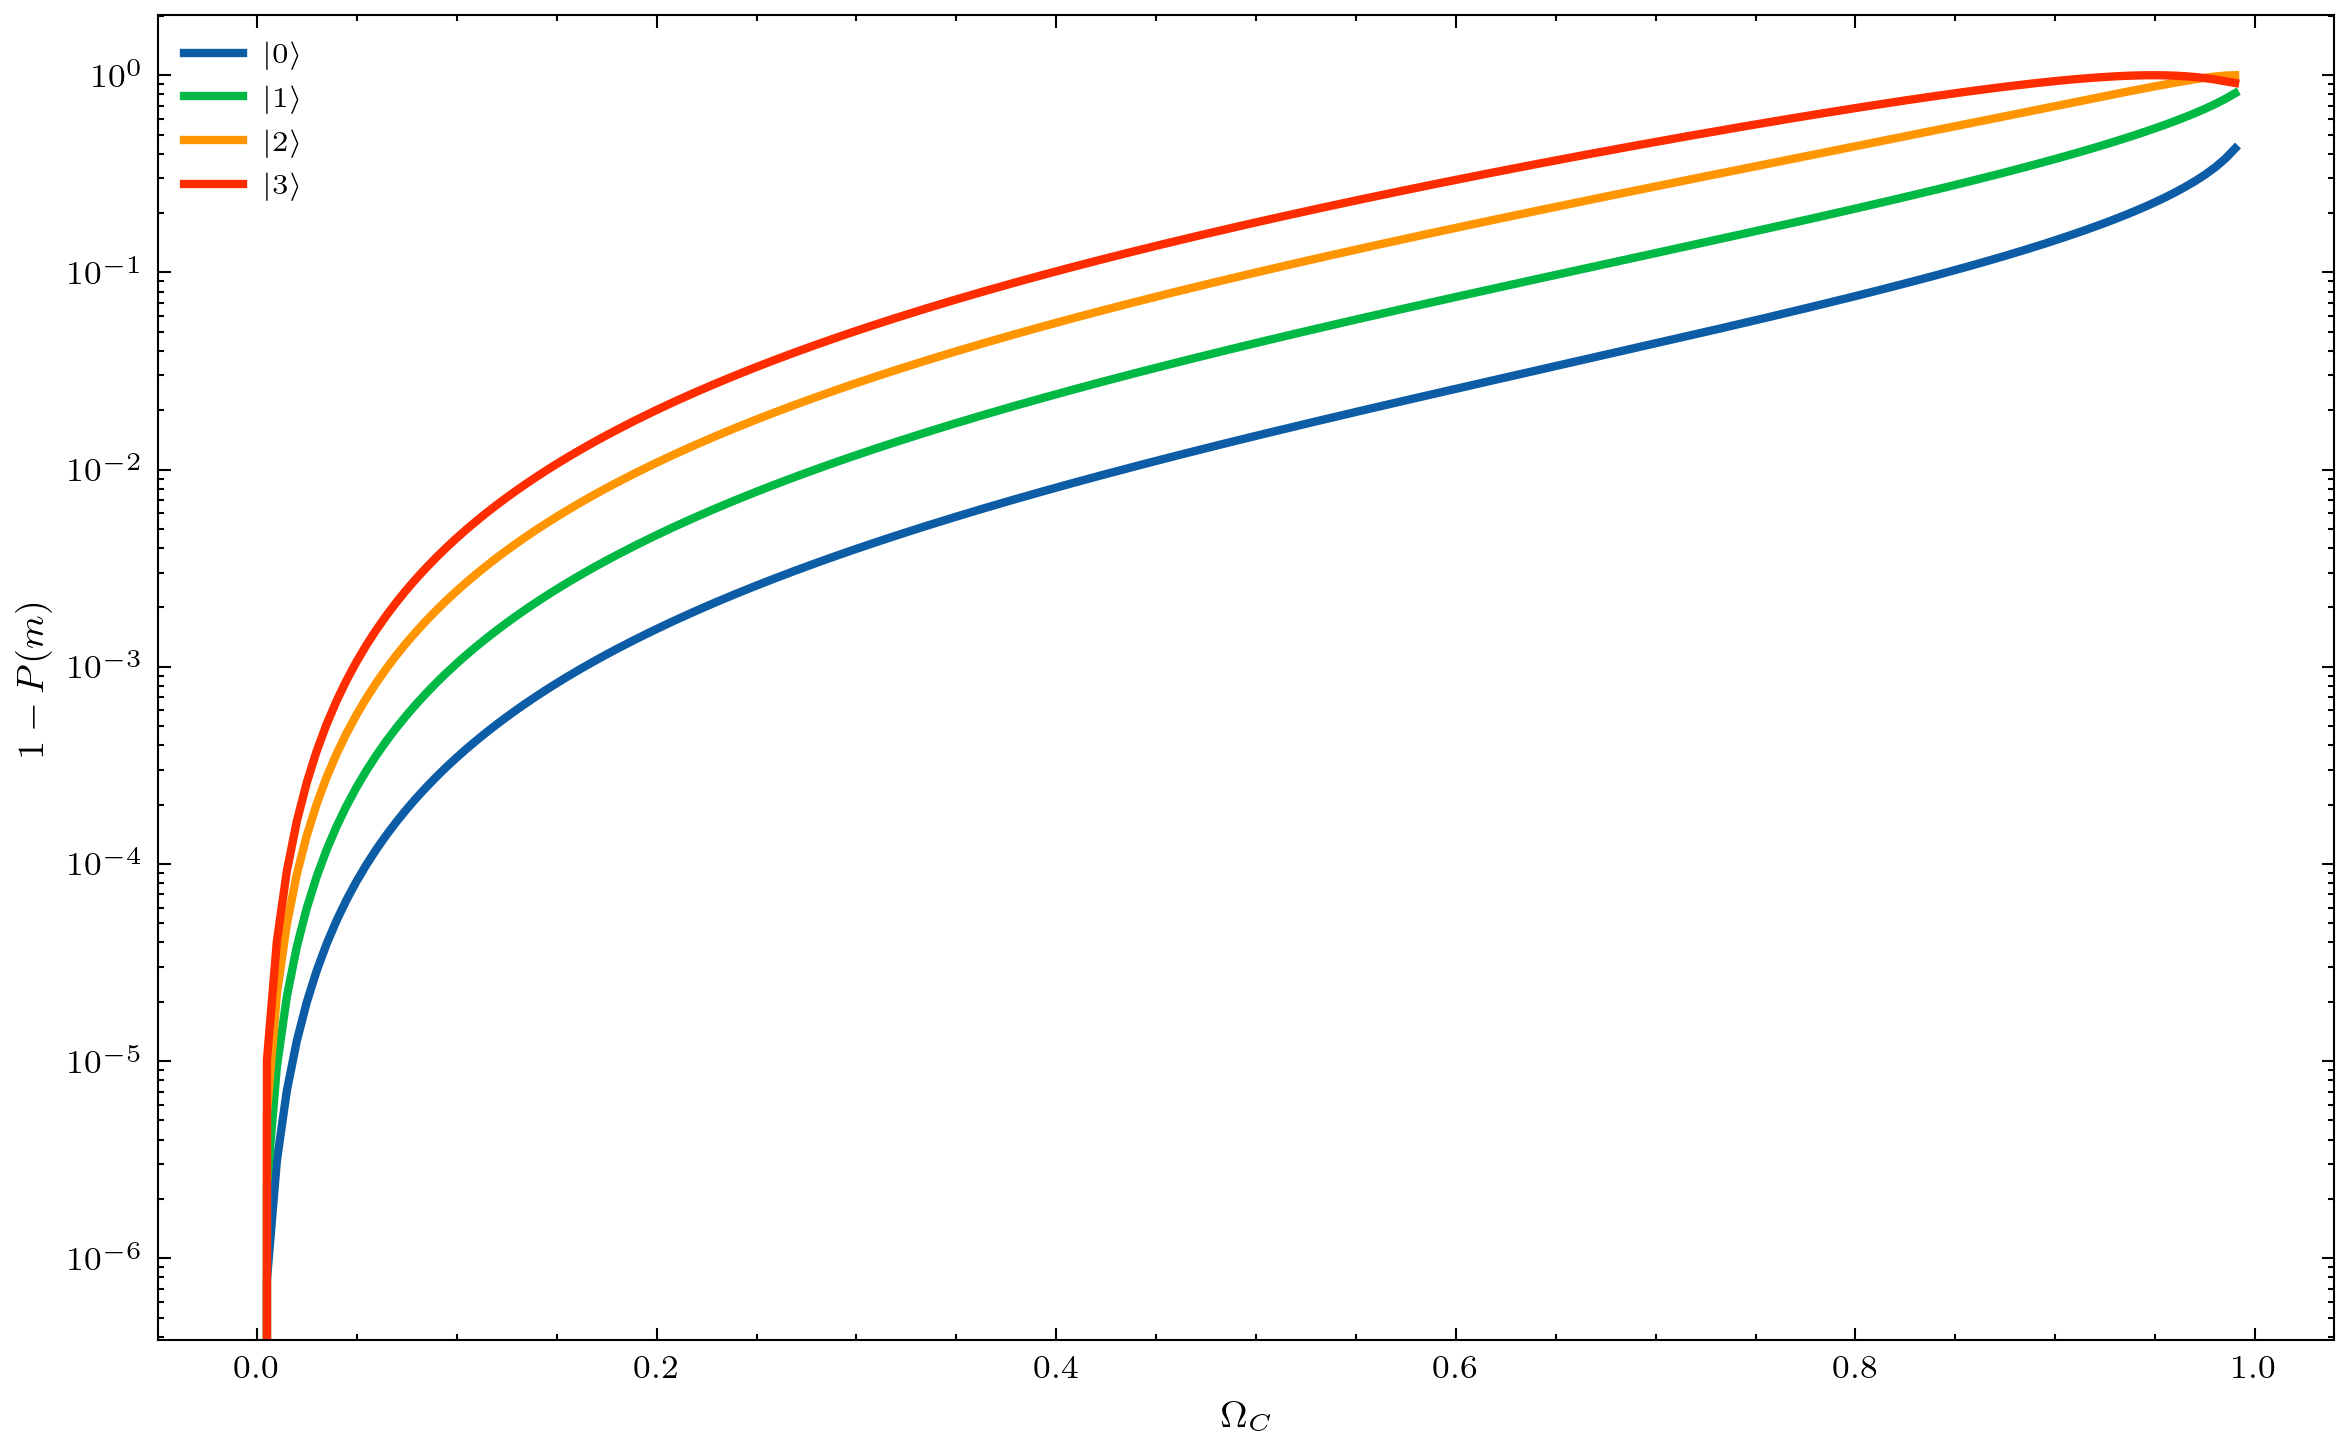

In [ ]:
Omega_C_values = np.linspace(0, 0.99, 200)
n_levels = 30

r_values = -0.25 * np.log(1 - Omega_C_values)

fig, ax = plt.subplots(figsize=(8, 5))  

for m in [0, 1, 2, 3]:
    pm = []
    for r in r_values:
        xi = r * np.exp(1j * 0.0)
        state = qt.squeeze(n_levels, xi) * qt.fock(n_levels, m)
        probs = np.abs(state.full().flatten())**2
        pm.append(probs[m])

    ax.plot(Omega_C_values, 1 - np.array(pm), label=f'$|{m}\\rangle$')

ax.set_yscale('log')
ax.set_xlabel(r'$\Omega_C$')
ax.set_ylabel(r'$1 - P(m)$')
ax.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, '$\\vert z_{\\alpha}(k = 0) \\vert$')

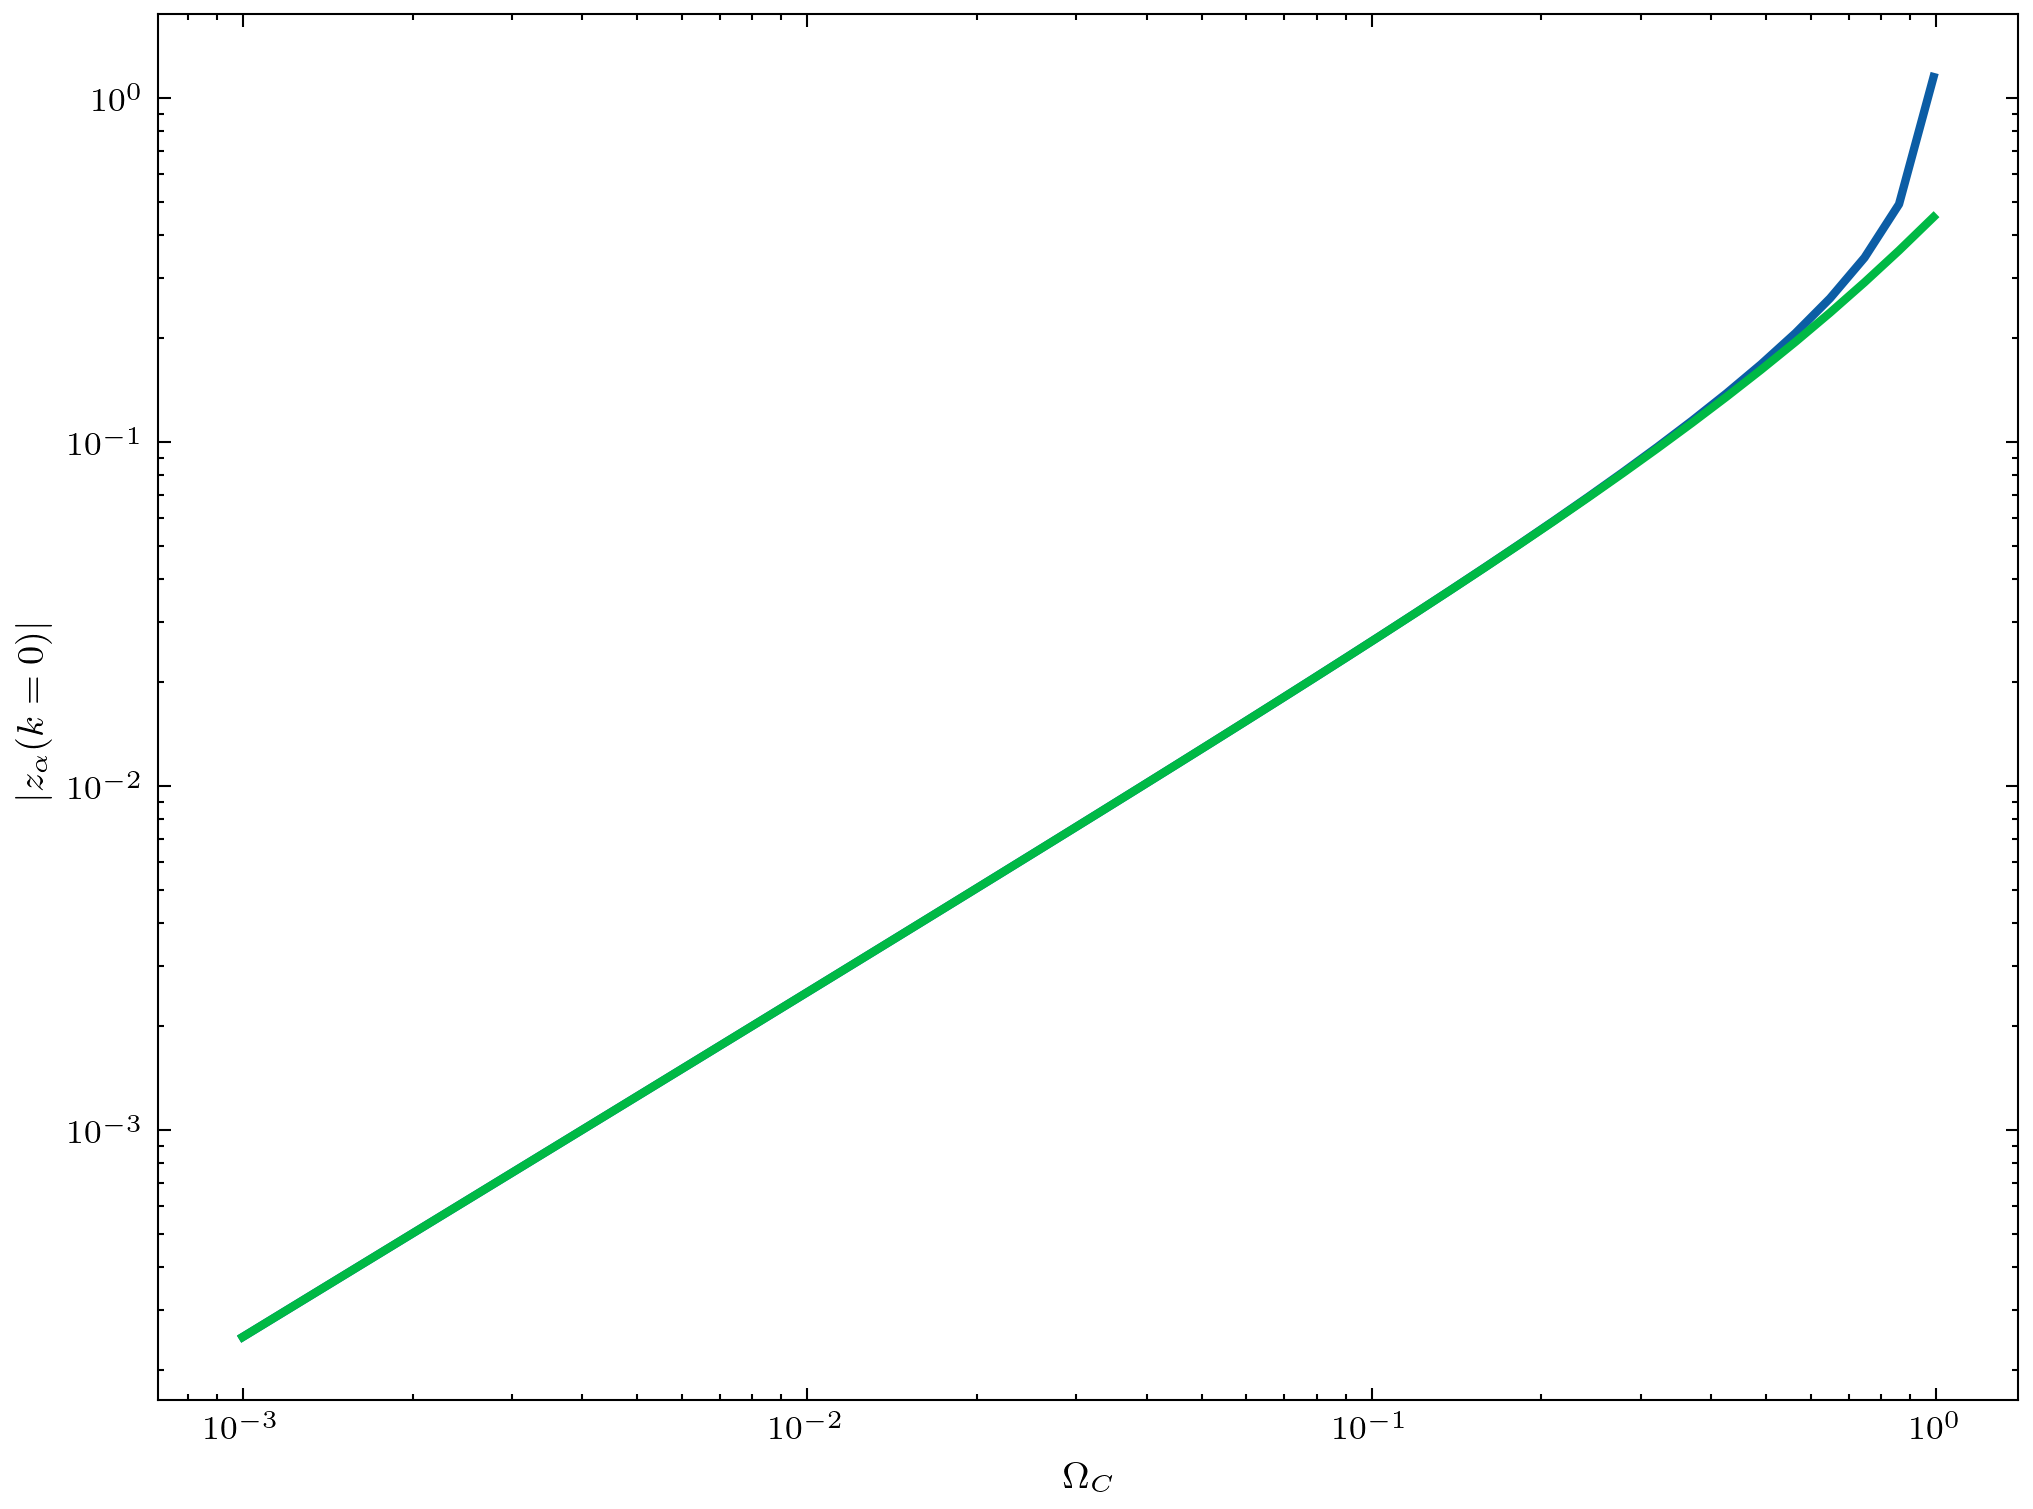

In [173]:
Omega_C_values = np.logspace(np.log10(0.001), np.log10(0.99))
# squeeze_parameter_values = 0.5 * np.atanh(0.5 * Omega_C_values / (1 - 0.5 * Omega_C_values ))
squeeze_parameter_values = -0.25 * np.log(1-Omega_C_values)
plt.yscale('log')
plt.xscale('log')
plt.plot(Omega_C_values, squeeze_parameter_values)
plt.plot(Omega_C_values, (Omega_C_values + 0.5 * Omega_C_values**2 + 0.3333 * Omega_C_values**3) / 4)
plt.xlabel(r'$\Omega_C$')
plt.ylabel(r'$\vert z_{\alpha}(k = 0) \vert$')